# Stabilizer Codes for Quantum Error Correction

## From repetition codes to the Steane code -- hands-on with Qiskit
---

### What This Notebook Covers

Quantum computers are inherently noisy — every gate, measurement, and idle period introduces errors. **Stabilizer codes** provide a systematic, algebraic framework for protecting quantum information by encoding logical qubits into entangled states of multiple physical qubits.

Unlike classical error correction (which simply copies bits), quantum error correction must work around the **no-cloning theorem** — we cannot copy an unknown quantum state. Stabilizer codes solve this by encoding information into the *joint properties* (stabilizers) of groups of qubits, allowing us to detect and correct errors without ever measuring the encoded data directly.

In this notebook, we will:

1. **Review the stabilizer formalism** — stabilizer generators, code spaces, the [[n,k,d]] notation, and how syndromes detect errors
2. **Build the 3-qubit bit-flip repetition code [[3,1,1]]** — encoding, syndrome extraction, and correction with classical feedforward
3. **Implement the [[5,1,3]] five-qubit perfect code** — the smallest code correcting any single-qubit error (X, Y, or Z)
4. **Construct the Steane code [[7,1,3]]** — a CSS code with independent X/Z error correction and transversal Clifford gates
5. **Compare all three codes** on a noisy FakeMarrakesh simulator to see real-world performance tradeoffs

---

## Background: The Stabilizer Formalism

### Pauli Group Recap

The **n-qubit Pauli group** $\mathcal{P}_n$ consists of all tensor products of single-qubit Pauli operators $\{I, X, Y, Z\}$ with phases $\{\pm 1, \pm i\}$. For example, on 3 qubits: $X \otimes Z \otimes I$ (written compactly as $XZI$) is a Pauli operator.

Key property: any two Pauli operators either **commute** ($PQ = QP$) or **anti-commute** ($PQ = -QP$). This binary distinction is the engine behind error detection.

### Stabilizer Codes: Definition

An **n-qubit stabilizer code** is defined by a set of **stabilizer generators** $P_1, \ldots, P_r$ — Pauli operators that satisfy three requirements:

1. **Commutativity**: All generators commute with one another: $[P_i, P_j] = 0$
2. **Minimality**: No generator can be derived as a product of the others
3. **Non-triviality**: At least one quantum state is fixed (eigenvalue $+1$) by all generators simultaneously

The **code space** $C$ is the simultaneous $+1$ eigenspace of all generators:

$$C = \{|\psi\rangle : P_k|\psi\rangle = |\psi\rangle \text{ for all } k = 1, \ldots, r\}$$

### The [[n, k, d]] Notation

A stabilizer code is characterized by three parameters:

| Parameter | Meaning |
|-----------|----------|
| $n$ | Number of **physical qubits** |
| $k = n - r$ | Number of **logical qubits** encoded |
| $d$ | **Code distance** — minimum weight of an undetectable error |

The code space has dimension $2^{n-r} = 2^k$, so $r$ generators on $n$ qubits encode $k = n - r$ logical qubits.

A code with distance $d$ can:
- **Detect** all errors of weight $< d$
- **Correct** all errors of weight $< d/2$ (i.e., up to $t = \lfloor(d-1)/2\rfloor$ errors)

### Error Detection via Syndromes

When an error $E$ occurs on an encoded state $|\psi\rangle \in C$, we measure each stabilizer generator $P_k$ to get an eigenvalue $s_k = \pm 1$. The **syndrome** is the vector $\mathbf{s} = (s_1, \ldots, s_r)$.

Three cases arise:

| Case | Condition | Syndrome | Effect |
|------|-----------|----------|--------|
| **Harmless** | $E$ is in the stabilizer group | All $+1$ | Acts as global phase — no damage |
| **Logical error** | $E$ commutes with all generators but is NOT in the stabilizer group | All $+1$ | Undetectable — changes the encoded data |
| **Detectable error** | $E$ anti-commutes with at least one generator | Some $-1$ | Detected — syndrome reveals the error |

The key insight: if $E$ anti-commutes with generator $P_k$, then $P_k(E|\psi\rangle) = -E(P_k|\psi\rangle) = -E|\psi\rangle$, so measuring $P_k$ yields $-1$ instead of $+1$.

### Correction Strategy

Given a syndrome $\mathbf{s}$, we find the **lowest-weight Pauli operator** $R$ that produces the same syndrome. Applying $R$ as a correction gives $RE|\psi\rangle$. If $RE$ is in the stabilizer group (acts as identity on the code space), the correction succeeds. For a distance-$d$ code, this strategy corrects all errors of weight $\lfloor(d-1)/2\rfloor$ or less.

### Clifford Operations

**Clifford operations** are unitaries that map Pauli operators to Pauli operators under conjugation: $UPU^\dagger = \pm Q$. They can be built from $\{H, S, \text{CNOT}\}$ gates. Clifford circuits are central to stabilizer codes because:
- Encoding circuits are Clifford circuits
- Syndrome extraction uses Clifford gates
- Many logical gates are transversal Clifford operations

---

## 1. Setup and Imports

In [55]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import product

# Qiskit core
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.quantum_info import (
    Statevector, DensityMatrix, Pauli, SparsePauliOp,
    StabilizerState, Clifford, state_fidelity
)
from qiskit.transpiler import generate_preset_pass_manager

# Qiskit IBM Runtime (noisy simulation)
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit_ibm_runtime.fake_provider import FakeMarrakesh

# Plotting style (matches LRCX template)
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

print("Libraries imported successfully!")

Libraries imported successfully!


---

## 2. Shared Helper Functions

These reusable utilities are used across all three codes for stabilizer verification, syndrome computation, and syndrome table construction.

In [56]:
def verify_stabilizers(circuit, generators):
    """
    Verify that the output state of a circuit is in the +1 eigenspace
    of all stabilizer generators.

    Args:
        circuit: QuantumCircuit producing the encoded state
        generators: list of Pauli strings (Qiskit convention: leftmost = highest qubit)
    Returns:
        dict: {generator_string: expectation_value}
    """
    sv = Statevector.from_instruction(circuit)
    results = {}
    for g in generators:
        exp_val = sv.expectation_value(Pauli(g))
        results[g] = np.real(exp_val)
    return results


def get_syndrome(circuit, generators):
    """
    Extract the error syndrome from a (possibly corrupted) encoded state.
    Returns the sign of each stabilizer expectation value as +1 or -1.
    """
    exp_vals = verify_stabilizers(circuit, generators)
    return [int(np.sign(v)) for v in exp_vals.values()]


def build_syndrome_table(generators, n_qubits):
    """
    Build a syndrome lookup table: syndrome tuple -> correction Pauli string.

    For each single-qubit X, Y, Z error, computes the syndrome algebraically
    using Pauli commutation. The correction IS the error (since P^2 = I).
    All Pauli strings use Qiskit convention (leftmost char = highest qubit).
    """
    table = {}
    table[tuple([1] * len(generators))] = 'I' * n_qubits

    for qubit in range(n_qubits):
        for pauli_label in ['X', 'Y', 'Z']:
            error_str = make_error_string(qubit, pauli_label, n_qubits)
            error_pauli = Pauli(error_str)

            syndrome = []
            for g in generators:
                commutes = Pauli(g).commutes(error_pauli)
                syndrome.append(1 if commutes else -1)

            syn_key = tuple(syndrome)
            if syn_key not in table:
                table[syn_key] = error_str

    return table


def check_commutativity(generators):
    """Verify all generators commute pairwise. Returns True if all commute."""
    all_commute = True
    for i in range(len(generators)):
        for j in range(i + 1, len(generators)):
            c = Pauli(generators[i]).commutes(Pauli(generators[j]))
            all_commute = all_commute and c
            print(f"  [{generators[i]}] & [{generators[j]}]: commute = {c}")
    return all_commute


def make_error_string(qubit, pauli_type, n_qubits):
    """
    Build a Pauli error string in Qiskit convention.
    Leftmost char = highest qubit, rightmost char = qubit 0.

    Example: make_error_string(0, 'X', 5) -> 'IIIIX'
    """
    chars = ['I'] * n_qubits
    chars[n_qubits - 1- qubit] = pauli_type
    return ''.join(chars)


def format_syndrome(syndrome):
    """Format a syndrome list as a compact +/- string."""
    return ''.join(['+' if s == 1 else '-' for s in syndrome])


def apply_pauli_string(qc, pauli_str, qubits=None):
    """
    Apply a Pauli string to circuit qubits.
    Qiskit convention: position i in string = qubit (n-1-i).

    Args:
        qc: QuantumCircuit
        pauli_str: Pauli string (Qiskit convention)
        qubits: optional qubit list/register; if None, uses circuit qubits 0..n-1
    """
    n = len(pauli_str)
    for i, p in enumerate(pauli_str):
        qubit_idx = n - 1 - i
        q = qubits[qubit_idx] if qubits is not None else qubit_idx
        if p == 'X': qc.x(q)
        elif p == 'Y': qc.y(q)
        elif p == 'Z': qc.z(q)


def ideal_syndrome_str(error_str, generators):
    """
    Compute ideal syndrome as a classical bit string.
    Returns bit string in Qiskit measurement order (leftmost = highest bit).

    Args:
        error_str: Pauli error string (Qiskit convention), or None for no error
        generators: list of Pauli strings
    """
    if error_str is None:
        return '0' * len(generators)
    error_pauli = Pauli(error_str)
    bits = []
    for g in generators:
        bits.append('0' if Pauli(g).commutes(error_pauli) else '1')
    return ''.join(bits)


print("Helper functions defined:")
print("  verify_stabilizers()   - check expectation values of stabilizer generators")
print("  get_syndrome()         - extract +1/-1 syndrome")
print("  build_syndrome_table() - syndrome -> correction lookup (Qiskit convention)")
print("  check_commutativity()  - verify all generators commute pairwise")
print("  make_error_string()    - build Pauli error string (Qiskit convention)")
print("  format_syndrome()      - format syndrome as +/- string")
print("  apply_pauli_string()   - apply Pauli string to circuit (Qiskit convention)")
print("  ideal_syndrome_str()   - compute ideal syndrome bit string")

Helper functions defined:
  verify_stabilizers()   - check expectation values of stabilizer generators
  get_syndrome()         - extract +1/-1 syndrome
  build_syndrome_table() - syndrome -> correction lookup (Qiskit convention)
  check_commutativity()  - verify all generators commute pairwise
  make_error_string()    - build Pauli error string (Qiskit convention)
  format_syndrome()      - format syndrome as +/- string
  apply_pauli_string()   - apply Pauli string to circuit (Qiskit convention)
  ideal_syndrome_str()   - compute ideal syndrome bit string


---

## 3. The 3-Qubit Bit-Flip Repetition Code [[3,1,1]]

### Theory

The simplest stabilizer code protects against **bit-flip (X) errors** by encoding a single logical qubit into three physical qubits:

$$|0_L\rangle = |000\rangle, \qquad |1_L\rangle = |111\rangle$$

**Stabilizer generators** (Qiskit convention: leftmost char = highest qubit):

| Generator | Pauli string | Qubits checked |
|-----------|-------------|----------------|
| $g_2 = Z_1 Z_2$ | `ZZI` | qubits 1 and 2 |
| $g_1 = Z_0 Z_1$ | `IZZ` | qubits 0 and 1 |

Both generators have eigenvalue $+1$ on valid codewords (all qubits agree) and eigenvalue $-1$ when the checked qubits disagree.

**Parameters:** $[[3, 1, 1]]$ — 3 physical qubits, $k = 3 - 2 = 1$ logical qubit. As a repetition code it corrects 1 bit-flip error via majority vote, though the formal distance is $d = 3$ for bit-flip errors only.

**Syndrome table** (corrections in Qiskit convention):

| Syndrome $(g_1, g_2)$ | Error | Correction |
|------------------------|-------|------------|
| $(+1, +1)$ | None | `III` |
| $(+1, -1)$ | $X$ on qubit 0 | `IIX` |
| $(-1, -1)$ | $X$ on qubit 1 | `IXI` |
| $(-1, +1)$ | $X$ on qubit 2 | `XII` |

### 3.1 Build the Encoding Circuit

3-Qubit Encoding Circuit:
  Qubits: 3
  Depth:  2
  Gates:  {'cx': 2}


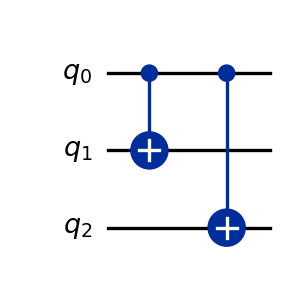

In [57]:
def encode_3qubit():
    """
    Encoding circuit for the 3-qubit bit-flip repetition code.
    
    Maps |psi>|00> -> alpha|000> + beta|111>.
    Qubit 0 is the logical data qubit; qubits 1,2 are ancillae.
    
    Returns:
        QuantumCircuit on 3 qubits implementing the encoding.
    """
    qc = QuantumCircuit(3, name='Encode_3bit')
    qc.cx(0, 1)
    qc.cx(0, 2)
    return qc


# Draw the encoding circuit
encode_circ = encode_3qubit()
print(f"3-Qubit Encoding Circuit:")
print(f"  Qubits: {encode_circ.num_qubits}")
print(f"  Depth:  {encode_circ.depth()}")
print(f"  Gates:  {dict(encode_circ.count_ops())}")
encode_circ.draw('mpl', style='iqp')

### 3.2 Verify Stabilizers with Statevector

Let's confirm that our encoding produces valid codewords by checking that every stabilizer generator has eigenvalue $+1$.

In [58]:
generators_3 = ['ZZI', 'IZZ']

# Encode |0> -> |000>  (logical zero)
qc_0L = QuantumCircuit(3)
qc_0L.compose(encode_3qubit(), inplace=True)

# Encode |1> -> |111>  (logical one)
qc_1L = QuantumCircuit(3)
qc_1L.x(0)
qc_1L.compose(encode_3qubit(), inplace=True)

# Encode |+> -> (|000> + |111>)/sqrt(2)  (logical plus / GHZ state)
qc_plus = QuantumCircuit(3)
qc_plus.h(0)
qc_plus.compose(encode_3qubit(), inplace=True)

print("Stabilizer Verification for 3-Qubit Code")
print("=" * 50)
for label, qc in [('|0_L> = |000>', qc_0L),
                   ('|1_L> = |111>', qc_1L),
                   ('|+_L> = GHZ',  qc_plus)]:
    result = verify_stabilizers(qc, generators_3)
    status = "PASS" if all(abs(v - 1.0) < 1e-10 for v in result.values()) else "FAIL"
    print(f"\n  {label}  [{status}]")
    for g, val in result.items():
        print(f"    <{g}> = {val:+.4f}")

Stabilizer Verification for 3-Qubit Code

  |0_L> = |000>  [PASS]
    <ZZI> = +1.0000
    <IZZ> = +1.0000

  |1_L> = |111>  [PASS]
    <ZZI> = +1.0000
    <IZZ> = +1.0000

  |+_L> = GHZ  [PASS]
    <ZZI> = +1.0000
    <IZZ> = +1.0000


### 3.3 Syndrome Extraction Circuit

To detect errors without destroying the encoded state, we use **ancilla qubits** to measure each stabilizer generator indirectly.

For the ZZ parity check: two CNOT gates from the data qubits to a shared ancilla compute the parity. If both data qubits are the same ($|00\rangle$ or $|11\rangle$), the ancilla stays $|0\rangle$ (syndrome $+1$). If they differ, the ancilla flips to $|1\rangle$ (syndrome $-1$).

```
data[0]: ──●─────────
           │
data[1]: ──│──●──────     Ancilla measures Z0*Z1 parity
           │  │
anc[0]:  ──⊕──⊕── M ──   outcome 0 → +1 (same), 1 → -1 (different)
```

Syndrome Extraction Circuit (3-qubit code):


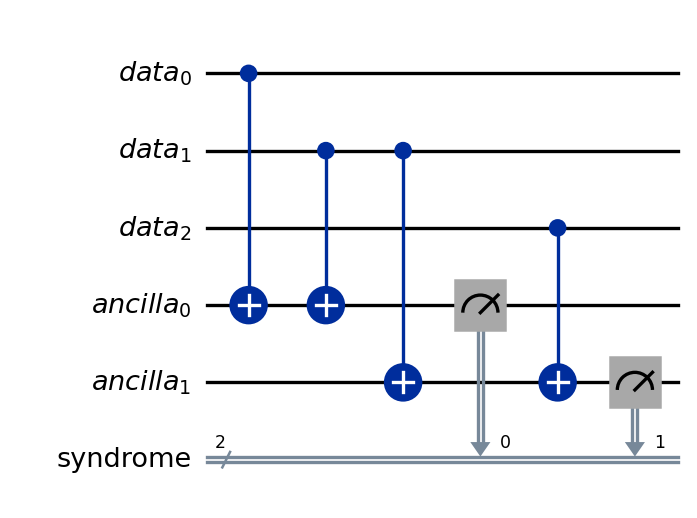

In [59]:
def syndrome_extraction_3qubit():
    """
    Build the syndrome extraction sub-circuit for the 3-qubit code.

    Uses 2 ancilla qubits to measure parity checks:
      - ancilla[0]: Z_0 Z_1 parity (data[0] and data[1])
      - ancilla[1]: Z_1 Z_2 parity (data[1] and data[2])

    Note: ancilla ordering matches circuit qubit order (low to high),
    which differs from generators_3 = ['ZZI', 'IZZ'] ordering.
    The full_pipeline_3qubit uses feedforward based on this circuit ordering.
    """
    data = QuantumRegister(3, 'data')
    anc = QuantumRegister(2, 'ancilla')
    syn = ClassicalRegister(2, 'syndrome')
    qc = QuantumCircuit(data, anc, syn, name='Syndrome_3bit')

    # Z_0 Z_1 parity: CNOT from data[0] and data[1] to ancilla[0]
    qc.cx(data[0], anc[0])
    qc.cx(data[1], anc[0])

    # Z_1 Z_2 parity: CNOT from data[1] and data[2] to ancilla[1]
    qc.cx(data[1], anc[1])
    qc.cx(data[2], anc[1])

    qc.measure(anc, syn)

    return qc


syn_circ = syndrome_extraction_3qubit()
print("Syndrome Extraction Circuit (3-qubit code):")
syn_circ.draw('mpl', style='iqp')

### 3.4 Ideal Error Detection Demo

Let's inject X errors on each qubit and observe the syndrome using ideal Statevector simulation.

In [60]:
print("3-Qubit Code: Syndrome Detection for Bit-Flip Errors")
print("=" * 55)
print(f"{'Error':<15} {'Syndrome (g2,g1)':<20} {'Correction'}")
print("-" * 55)

syndrome_table_3 = build_syndrome_table(generators_3, 3)

for error_q in [None, 0, 1, 2]:
    qc = QuantumCircuit(3)
    qc.h(0)
    qc.compose(encode_3qubit(), inplace=True)

    if error_q is not None:
        qc.x(error_q)

    syndrome = get_syndrome(qc, generators_3)
    error_label = f"X on qubit {error_q}" if error_q is not None else "None"
    correction = syndrome_table_3.get(tuple(syndrome), "UNKNOWN")
    syn_str = format_syndrome(syndrome)

    print(f"  {error_label:<15} ({syn_str}){'':>12} {correction}")

print("\nEach single-qubit X error produces a unique syndrome!")
print("Correction strings use Qiskit convention (leftmost = highest qubit).")

3-Qubit Code: Syndrome Detection for Bit-Flip Errors
Error           Syndrome (g2,g1)     Correction
-------------------------------------------------------
  None            (++)             III
  X on qubit 0    (+-)             IIX
  X on qubit 1    (--)             IXI
  X on qubit 2    (-+)             XII

Each single-qubit X error produces a unique syndrome!
Correction strings use Qiskit convention (leftmost = highest qubit).


### 3.5 Full Pipeline: Encode → Error → Syndrome → Correct → Decode

Now we build the complete error correction pipeline as a single circuit using **classical feedforward** — the syndrome measurement outcomes directly control the correction gates in real-time.

The correction logic maps syndrome register values to X corrections:
- `syndrome = 0b01` → $X$ on qubit 0
- `syndrome = 0b11` → $X$ on qubit 1  
- `syndrome = 0b10` → $X$ on qubit 2

Full 3-Qubit Error Correction Pipeline (X error on qubit 1):
  Total qubits: 5
  Circuit depth: 16


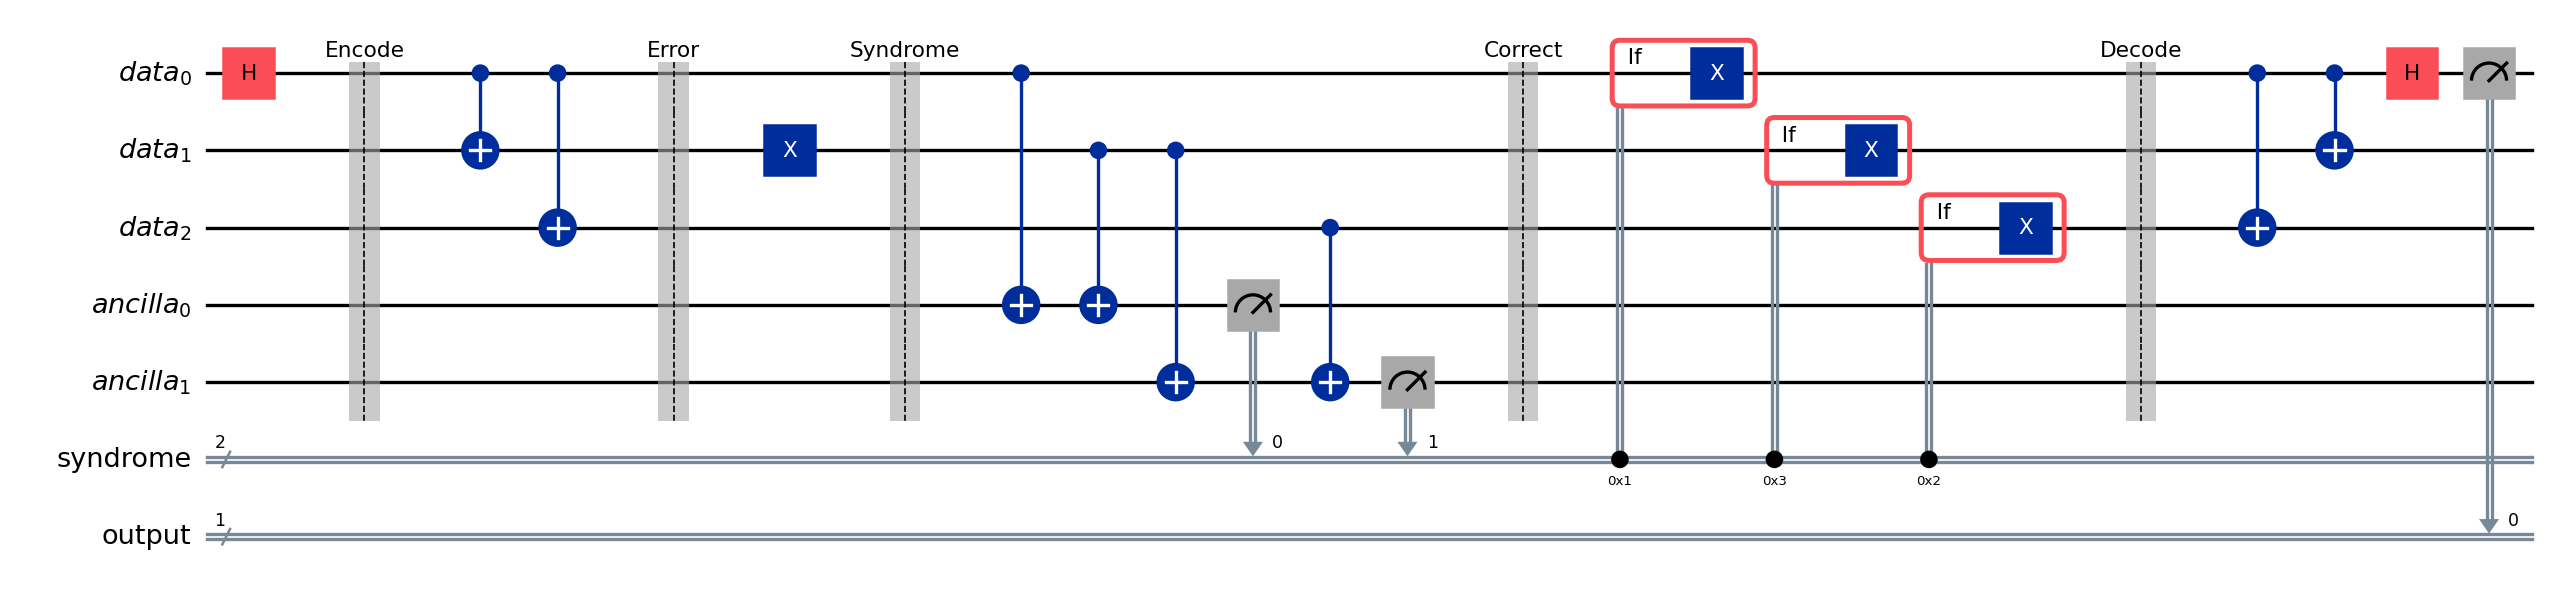

In [61]:
def full_pipeline_3qubit(error_qubit=None, initial_state='plus'):
    """
    Complete encode -> error -> syndrome -> correct -> decode pipeline
    for the 3-qubit bit-flip code.
    
    Uses classical feedforward (qc.if_test) to apply corrections
    based on syndrome measurement outcomes — no classical post-processing needed.
    
    Args:
        error_qubit: which qubit to apply X error to (None = no error)
        initial_state: 'plus' for |+> or 'zero' for |0>
    
    Returns:
        QuantumCircuit with the full pipeline.
    """
    data = QuantumRegister(3, 'data')
    anc = QuantumRegister(2, 'ancilla')
    syn = ClassicalRegister(2, 'syndrome')
    out = ClassicalRegister(1, 'output')
    qc = QuantumCircuit(data, anc, syn, out)
    
    # 1. Prepare initial state on qubit 0
    if initial_state == 'plus':
        qc.h(data[0])
    elif initial_state == 'one':
        qc.x(data[0])
    qc.barrier(label='Encode')
    
    # 2. Encode: |psi>|00> -> alpha|000> + beta|111>
    qc.cx(data[0], data[1])
    qc.cx(data[0], data[2])
    qc.barrier(label='Error')
    
    # 3. Inject error (single-qubit X)
    if error_qubit is not None:
        qc.x(data[error_qubit])
    qc.barrier(label='Syndrome')
    
    # 4. Syndrome extraction
    qc.cx(data[0], anc[0])  # g1 = Z0*Z1
    qc.cx(data[1], anc[0])
    qc.cx(data[1], anc[1])  # g2 = Z1*Z2
    qc.cx(data[2], anc[1])
    qc.measure(anc, syn)
    qc.barrier(label='Correct')
    
    # 5. Classical feedforward corrections
    # syndrome register: bit 0 = g1, bit 1 = g2
    # 0b01 (=1): g1=-1, g2=+1 -> error on qubit 0
    with qc.if_test((syn, 0b01)):
        qc.x(data[0])
    # 0b11 (=3): g1=-1, g2=-1 -> error on qubit 1
    with qc.if_test((syn, 0b11)):
        qc.x(data[1])
    # 0b10 (=2): g1=+1, g2=-1 -> error on qubit 2
    with qc.if_test((syn, 0b10)):
        qc.x(data[2])
    qc.barrier(label='Decode')
    
    # 6. Decode: reverse the encoding
    qc.cx(data[0], data[2])
    qc.cx(data[0], data[1])
    
    # 7. Measure the logical qubit
    if initial_state == 'plus':
        qc.h(data[0])
    qc.measure(data[0], out[0])
    
    return qc


# Draw the full pipeline with error on qubit 1
demo_pipeline = full_pipeline_3qubit(error_qubit=1)
print("Full 3-Qubit Error Correction Pipeline (X error on qubit 1):")
print(f"  Total qubits: {demo_pipeline.num_qubits}")
print(f"  Circuit depth: {demo_pipeline.depth()}")
demo_pipeline.draw('mpl', style='iqp', fold=-1, idle_wires=False)

### 3.6 Noisy Simulation on FakeMarrakesh

Let's run the full pipeline on a **noisy simulator** that replicates the error rates of a real IBM Quantum backend. We test with and without errors and measure the correction success rate.

3-Qubit Code: Noisy Simulation on FakeMarrakesh
Backend: fake_marrakesh, Shots: 4096

  No error      counts: {'0': 4008, '1': 88}  success rate: 97.9%
  X on q0       counts: {'0': 3942, '1': 154}  success rate: 96.2%
  X on q1       counts: {'0': 3958, '1': 138}  success rate: 96.6%
  X on q2       counts: {'0': 3994, '1': 102}  success rate: 97.5%


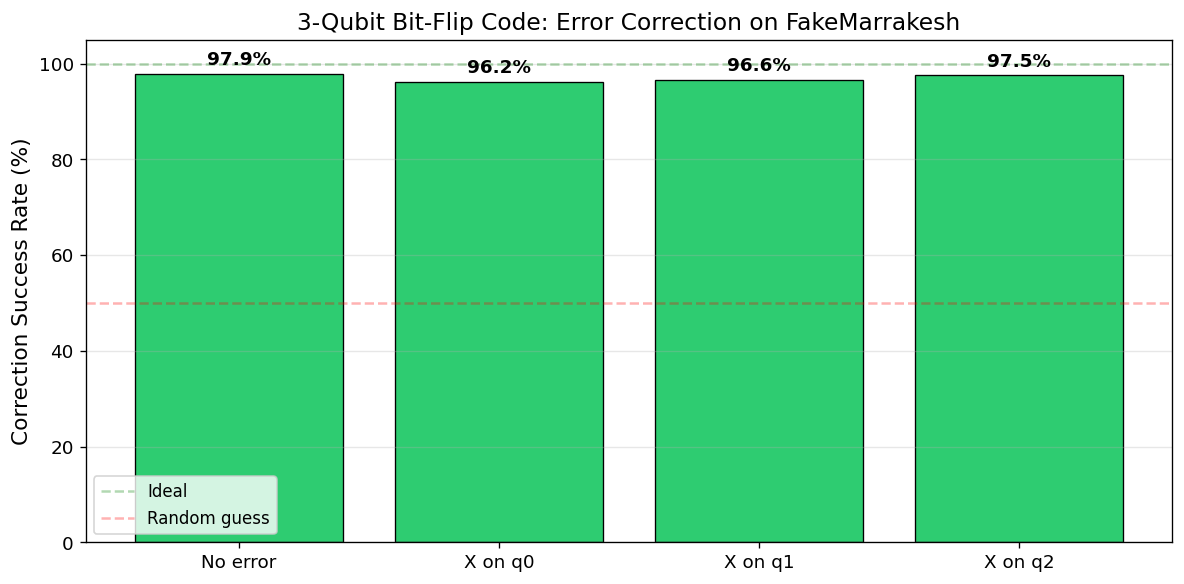


Note: Success rates < 100% reflect gate errors and measurement noise
in the FakeMarrakesh noise model, not failures of the code itself.


In [62]:
# ---- FakeMarrakesh setup ----
fake_backend = FakeMarrakesh()
pm_fake = generate_preset_pass_manager(optimization_level=1, backend=fake_backend)
sampler = Sampler(mode=fake_backend)

SHOTS = 4096

# ---- Build and run pipelines for all error cases ----
# For |+> input, after successful correction and decode, 
# we expect output 0 and 1 with equal probability (50/50).
# For |0> input, we expect output 0 with ~100% probability.

print("3-Qubit Code: Noisy Simulation on FakeMarrakesh")
print("=" * 65)
print(f"Backend: {fake_backend.name}, Shots: {SHOTS}")
print()

# Test with |0> initial state (expect output = 0 always after correction)
error_cases = {
    'No error': None,
    'X on q0': 0,
    'X on q1': 1,
    'X on q2': 2,
}

results_3q = {}
for label, error_q in error_cases.items():
    qc = full_pipeline_3qubit(error_qubit=error_q, initial_state='zero')
    isa_qc = pm_fake.run(qc)
    job = sampler.run([isa_qc], shots=SHOTS)
    counts = job.result()[0].data.output.get_counts()
    
    # Success = measuring |0> (the original encoded state)
    success_count = counts.get('0', 0)
    success_rate = success_count / SHOTS * 100
    results_3q[label] = success_rate
    
    print(f"  {label:<12}  counts: {counts}  success rate: {success_rate:.1f}%")

# ---- Bar chart ----
fig, ax = plt.subplots(figsize=(10, 5))
labels = list(results_3q.keys())
rates = list(results_3q.values())
colors = ['#2ecc71' if r > 90 else '#e74c3c' for r in rates]

bars = ax.bar(labels, rates, color=colors, edgecolor='black', linewidth=0.8)
ax.axhline(y=100, color='green', linestyle='--', alpha=0.3, label='Ideal')
ax.axhline(y=50, color='red', linestyle='--', alpha=0.3, label='Random guess')
ax.set_ylabel('Correction Success Rate (%)', fontsize=13)
ax.set_title('3-Qubit Bit-Flip Code: Error Correction on FakeMarrakesh', fontsize=14)
ax.set_ylim(0, 105)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

for bar, rate in zip(bars, rates):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
            f'{rate:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print("\nNote: Success rates < 100% reflect gate errors and measurement noise")
print("in the FakeMarrakesh noise model, not failures of the code itself.")

---

## 4. The [[5,1,3]] Five-Qubit Perfect Code

### Theory

The **five-qubit code** is the smallest quantum error-correcting code that can correct an **arbitrary single-qubit error** — whether it's a bit-flip ($X$), phase-flip ($Z$), or both ($Y = iXZ$). It is called "perfect" because it saturates the quantum Hamming bound: with $n = 5$ physical qubits and $k = 1$ logical qubit, we need $r = 4$ generators, and the $2^4 = 16$ syndrome values exactly match the 15 possible single-qubit errors (3 Pauli types $\times$ 5 qubits) plus the no-error case.

**Stabilizer generators** (cyclic structure):

| Generator | Pauli string | 
|-----------|-------------|
| $g_4$ | `XZZXI` |
| $g_3$ | `IXZZX` |
| $g_2$ | `XIXZZ` |
| $g_1$ | `ZXIXZ` |

Each generator is a cyclic shift of the pattern $XZZXI$, which reflects the code's elegant algebraic structure.

**Parameters:** $[[5, 1, 3]]$ — 5 physical qubits, $k = 5 - 4 = 1$ logical qubit, distance $d = 3$ (corrects $t = \lfloor(3-1)/2\rfloor = 1$ arbitrary error).

**Logical operators:**
$$X_L = XXXXX, \qquad Z_L = ZZZZZ$$

These commute with all stabilizer generators (so they preserve the code space) but are not in the stabilizer group (so they flip the logical qubit).

### 4.1 Verify Generator Properties and Build Syndrome Table

In [63]:
generators_5 = ['XZZXI', 'IXZZX', 'XIXZZ', 'ZXIXZ']

print("Generator Commutativity Check")
print("=" * 50)
all_commute = check_commutativity(generators_5)
print(f"\nAll generators commute: {all_commute}")

print("\nLogical Operator Commutativity")
print("-" * 50)
for log_op, log_label in [('XXXXX', 'X_L'), ('ZZZZZ', 'Z_L')]:
    for gen in generators_5:
        c = Pauli(log_op).commutes(Pauli(gen))
        print(f"  {log_label} & {gen}: commute = {c}")

syndrome_table_5 = build_syndrome_table(generators_5, 5)

print(f"\nSyndrome Table ({len(syndrome_table_5)} entries):")
print(f"  Expected: 16 (1 no-error + 15 single-qubit errors)")
print(f"  Actual:   {len(syndrome_table_5)}")
print(f"\n{'Syndrome':<25} {'Correction':<10}")
print("-" * 35)
for syndrome, correction in sorted(syndrome_table_5.items(), key=lambda x: x[1]):
    print(f"  ({format_syndrome(syndrome)})    {correction}")

Generator Commutativity Check
  [XZZXI] & [IXZZX]: commute = True
  [XZZXI] & [XIXZZ]: commute = True
  [XZZXI] & [ZXIXZ]: commute = True
  [IXZZX] & [XIXZZ]: commute = True
  [IXZZX] & [ZXIXZ]: commute = True
  [XIXZZ] & [ZXIXZ]: commute = True

All generators commute: True

Logical Operator Commutativity
--------------------------------------------------
  X_L & XZZXI: commute = True
  X_L & IXZZX: commute = True
  X_L & XIXZZ: commute = True
  X_L & ZXIXZ: commute = True
  Z_L & XZZXI: commute = True
  Z_L & IXZZX: commute = True
  Z_L & XIXZZ: commute = True
  Z_L & ZXIXZ: commute = True

Syndrome Table (16 entries):
  Expected: 16 (1 no-error + 15 single-qubit errors)
  Actual:   16

Syndrome                  Correction
-----------------------------------
  (++++)    IIIII
  (++--)    IIIIX
  (+---)    IIIIY
  (+-++)    IIIIZ
  (+--+)    IIIXI
  (----)    IIIYI
  (-++-)    IIIZI
  (--++)    IIXII
  (---+)    IIYII
  (++-+)    IIZII
  (-+++)    IXIII
  (--+-)    IYIII
  (+-+-)    I

### 4.2 Build the Encoding Circuit

The encoding circuit maps $|\psi\rangle|0000\rangle \to |\psi_L\rangle$. We use the standard construction from Gottesman's encoding algorithm: initialize 4 ancilla qubits, apply Hadamards, then entangle using CX/CZ gates derived from the stabilizer generators.

We use qubit 0 as the logical input and qubits 1-4 as ancillae.

5-Qubit Encoding Circuit:
  Qubits: 5
  Depth:  17
  Gates:  {'cx': 9, 's': 7, 'h': 6, 'swap': 3, 'z': 2, 'y': 1, 'x': 1}


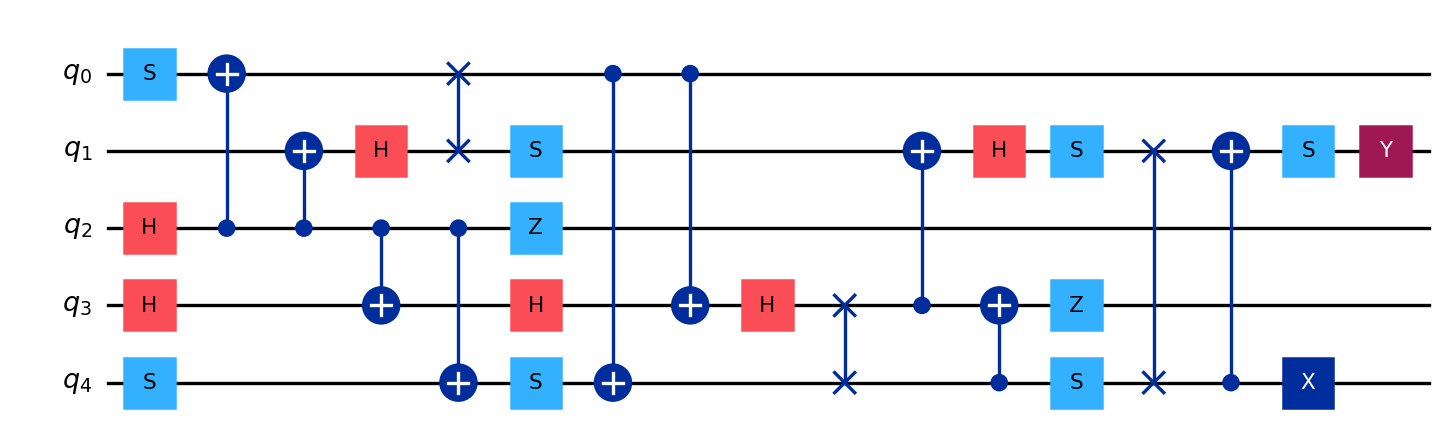

In [64]:
def encode_5qubit():
    """Encoding circuit for [[5,1,3]] derived from StabilizerState."""
    stab = StabilizerState.from_stabilizer_list(generators_5 + ['ZZZZZ'])
    return stab.clifford.to_circuit()


enc5 = encode_5qubit()
print(f"5-Qubit Encoding Circuit:")
print(f"  Qubits: {enc5.num_qubits}")
print(f"  Depth:  {enc5.depth()}")
print(f"  Gates:  {dict(enc5.count_ops())}")
enc5.draw('mpl', style='iqp')

### 4.3 Verify the Encoding

This is a critical step — we verify that the encoding circuit actually produces a valid codeword by checking all stabilizer generators. If any expectation value is not $+1$, we know the encoding is wrong.

We also verify the logical operators $X_L$ and $Z_L$.

In [73]:
print("5-Qubit Code: Encoding Verification")
print("=" * 55)

# Encode |0> -> |0_L>
qc_0L_5 = QuantumCircuit(5)
qc_0L_5.compose(encode_5qubit(), inplace=True)

# |1_L> = X_L |0_L>, where X_L = XXXXX
qc_1L_5 = QuantumCircuit(5)
qc_1L_5.compose(encode_5qubit(), inplace=True)
for i in range(5):
    qc_1L_5.x(i)

for label, qc in [('|0_L>', qc_0L_5), ('|1_L>', qc_1L_5)]:
    result = verify_stabilizers(qc, generators_5)
    all_pass = all(abs(v - 1.0) < 1e-10 for v in result.values())
    print(f"\n  {label}  [{'PASS' if all_pass else 'FAIL'}]")
    for g, val in result.items():
        status = "ok" if abs(val - 1.0) < 1e-10 else "FAIL"
        print(f"    <{g}> = {val:+.6f}  [{status}]")

print("\nLogical Operator Expectations:")
print("-" * 40)
sv_0L = Statevector.from_instruction(qc_0L_5)
sv_1L = Statevector.from_instruction(qc_1L_5)

zl_0 = np.real(sv_0L.expectation_value(Pauli('ZZZZZ')))
zl_1 = np.real(sv_1L.expectation_value(Pauli('ZZZZZ')))

print(f"  <0_L|Z_L|0_L> = {zl_0:+.4f}  (expect +1)")
print(f"  <1_L|Z_L|1_L> = {zl_1:+.4f}  (expect -1)")

print("\n|0_L> Codeword Structure:")
print("-" * 45)
probs = sv_1L.probabilities_dict()
nonzero = {k: v for k, v in sorted(probs.items()) if v > 1e-10}
print(f"  {len(nonzero)} basis states with equal amplitude 1/sqrt({len(nonzero)}):")
for bitstring, prob in nonzero.items():
    print(f"    |{bitstring}> : probability = {prob:.4f}")

5-Qubit Code: Encoding Verification

  |0_L>  [PASS]
    <XZZXI> = +1.000000  [ok]
    <IXZZX> = +1.000000  [ok]
    <XIXZZ> = +1.000000  [ok]
    <ZXIXZ> = +1.000000  [ok]

  |1_L>  [PASS]
    <XZZXI> = +1.000000  [ok]
    <IXZZX> = +1.000000  [ok]
    <XIXZZ> = +1.000000  [ok]
    <ZXIXZ> = +1.000000  [ok]

Logical Operator Expectations:
----------------------------------------
  <0_L|Z_L|0_L> = +1.0000  (expect +1)
  <1_L|Z_L|1_L> = -1.0000  (expect -1)

|0_L> Codeword Structure:
---------------------------------------------
  16 basis states with equal amplitude 1/sqrt(16):
    |00001> : probability = 0.0625
    |00010> : probability = 0.0625
    |00100> : probability = 0.0625
    |00111> : probability = 0.0625
    |01000> : probability = 0.0625
    |01011> : probability = 0.0625
    |01101> : probability = 0.0625
    |01110> : probability = 0.0625
    |10000> : probability = 0.0625
    |10011> : probability = 0.0625
    |10101> : probability = 0.0625
    |10110> : probability = 0.

### 4.4 Syndrome Extraction for Arbitrary Errors

For a general stabilizer measurement (not just Z-type), we use an ancilla qubit prepared in $|+\rangle$ and apply controlled-Pauli operations. The general protocol for measuring generator $g_k = P_{k,1} \otimes \cdots \otimes P_{k,n}$:

1. Initialize ancilla in $|+\rangle$ (apply $H$)
2. For each qubit $i$: if $P_{k,i} = X$, apply $\text{CNOT}(\text{data}_i, \text{anc})$; if $P_{k,i} = Z$, apply $\text{CZ}(\text{data}_i, \text{anc})$; if $P_{k,i} = Y$, apply both
3. Apply $H$ to ancilla and measure

Outcome 0 → eigenvalue $+1$; outcome 1 → eigenvalue $-1$.

5-Qubit Syndrome Extraction Circuit:
  Data qubits:    5
  Ancilla qubits: 4
  Total qubits:   9
  Circuit depth:  29


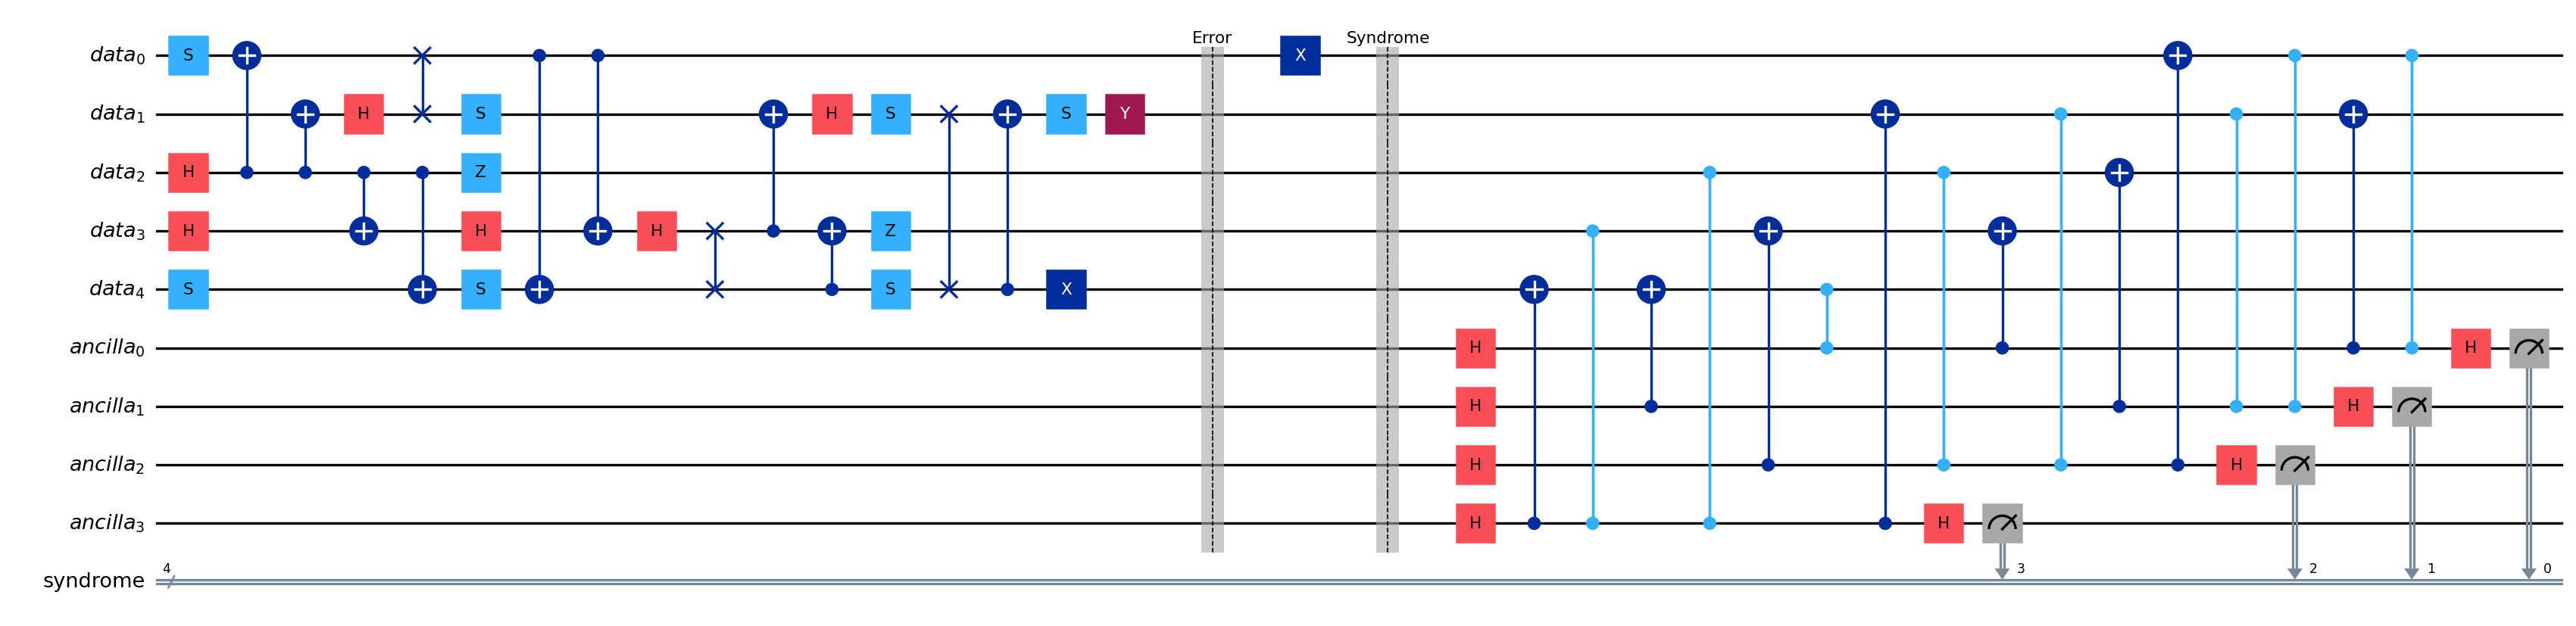

In [66]:
def build_syndrome_circuit(encoding_fn, generators, n_data, error_pauli_str=None):
    """
    Build a full encode -> error -> syndrome extraction circuit
    for any stabilizer code using the indirect measurement protocol.

    Protocol: H(anc) -> controlled-P -> H(anc) -> measure
    - For Z on data: use CZ(data, anc)  [symmetric]
    - For X on data: use CX(anc, data)  [ancilla controls data]
    - For Y on data: use CX(anc, data) then CZ(data, anc)

    Args:
        encoding_fn: callable returning a QuantumCircuit for encoding
        generators: list of Pauli strings (Qiskit convention)
        n_data: number of data qubits
        error_pauli_str: Pauli error string (Qiskit convention), or None
    """
    n_gen = len(generators)
    data = QuantumRegister(n_data, 'data')
    anc = QuantumRegister(n_gen, 'ancilla')
    syn = ClassicalRegister(n_gen, 'syndrome')
    qc = QuantumCircuit(data, anc, syn)

    qc.compose(encoding_fn(), qubits=data, inplace=True)
    qc.barrier(label='Error')

    if error_pauli_str:
        apply_pauli_string(qc, error_pauli_str, qubits=data)
    qc.barrier(label='Syndrome')

    n_gen = len(generators)
    for k, gen in enumerate(generators):
        a = n_gen - 1 - k  # g1 -> anc[3], g4 -> anc[0]
        qc.h(anc[a])
        for j, p in enumerate(gen):
            qubit = n_data - 1 - j
            if p == "X":
                qc.cx(anc[a], data[qubit])
            elif p == "Z":
                qc.cz(data[qubit], anc[a])
            elif p == "Y":
                qc.cx(anc[a], data[qubit])
                qc.cz(data[qubit], anc[a])
        qc.h(anc[a])
        qc.measure(anc[a], syn[a])

    return qc


demo_syn5 = build_syndrome_circuit(encode_5qubit, generators_5, 5, "X")
print(f"5-Qubit Syndrome Extraction Circuit:")
print(f"  Data qubits:    {5}")
print(f"  Ancilla qubits: {len(generators_5)}")
print(f"  Total qubits:   {demo_syn5.num_qubits}")
print(f"  Circuit depth:  {demo_syn5.depth()}")
demo_syn5.draw('mpl', style='iqp', fold=-1, idle_wires=False)

### 4.5 Demonstrate Error Detection for All Single-Qubit Errors

Unlike the 3-qubit code (which only detects X errors), the [[5,1,3]] code produces **unique syndromes for all 15 single-qubit errors** — X, Y, and Z on each of the 5 qubits.

In [67]:
print("5-Qubit Code: Syndrome for Every Single-Qubit Error")
print("=" * 65)
print(f"{'Error':<12} {'Syndrome (g4,g3,g2,g1)':<28} {'Correction'}")
print("-" * 65)

qc_no_err = QuantumCircuit(5)
qc_no_err.compose(encode_5qubit(), inplace=True)
syndrome_no_err = get_syndrome(qc_no_err, generators_5)
print(f"  {'None':<12} ({format_syndrome(syndrome_no_err)}){'':>14} {'IIIII'}")

syndromes_seen = set()
for qubit in range(5):
    for pauli in ['X', 'Y', 'Z']:
        error_label = make_error_string(qubit, pauli, 5)

        qc = QuantumCircuit(5)
        qc.compose(encode_5qubit(), inplace=True)
        if pauli == 'X': qc.x(qubit)
        elif pauli == 'Y': qc.y(qubit)
        elif pauli == 'Z': qc.z(qubit)

        syndrome = get_syndrome(qc, generators_5)
        syn_tuple = tuple(syndrome)
        syndromes_seen.add(syn_tuple)
        correction = syndrome_table_5.get(syn_tuple, 'UNKNOWN')

        print(f"  {error_label:<12} ({format_syndrome(syndrome)}){'':>14} {correction}")

print(f"\nUnique syndromes: {len(syndromes_seen)+1} (expected: 16)")
print("All 15 single-qubit errors produce distinct syndromes!")

5-Qubit Code: Syndrome for Every Single-Qubit Error
Error        Syndrome (g4,g3,g2,g1)       Correction
-----------------------------------------------------------------
  None         (++++)               IIIII
  IIIIX        (++--)               IIIIX
  IIIIY        (+---)               IIIIY
  IIIIZ        (+-++)               IIIIZ
  IIIXI        (+--+)               IIIXI
  IIIYI        (----)               IIIYI
  IIIZI        (-++-)               IIIZI
  IIXII        (--++)               IIXII
  IIYII        (---+)               IIYII
  IIZII        (++-+)               IIZII
  IXIII        (-+++)               IXIII
  IYIII        (--+-)               IYIII
  IZIII        (+-+-)               IZIII
  XIIII        (+++-)               XIIII
  YIIII        (-+--)               YIIII
  ZIIII        (-+-+)               ZIIII

Unique syndromes: 16 (expected: 16)
All 15 single-qubit errors produce distinct syndromes!


### 4.6 Full Error Correction Verification

We verify that applying the syndrome-identified correction restores the original encoded state with fidelity 1.0 for all 15 single-qubit errors.

In [68]:
qc_ref = QuantumCircuit(5)
qc_ref.compose(encode_5qubit(), inplace=True)
sv_ref = Statevector.from_instruction(qc_ref)

print("5-Qubit Code: Error Correction Fidelity Verification")
print("=" * 65)
print(f"{'Error':<12} {'Syndrome':<15} {'Correction':<12} {'Fidelity':<10} {'Status'}")
print("-" * 65)

all_pass = True
for qubit in range(5):
    for pauli in ['X', 'Y', 'Z']:
        error_label = make_error_string(qubit, pauli, 5)

        qc = QuantumCircuit(5)
        qc.compose(encode_5qubit(), inplace=True)
        apply_pauli_string(qc, error_label)

        syndrome = get_syndrome(qc, generators_5)
        correction = syndrome_table_5.get(tuple(syndrome), None)

        if correction:
            apply_pauli_string(qc, correction)

        sv_corrected = Statevector.from_instruction(qc)
        fid = state_fidelity(sv_corrected, sv_ref)

        status = "PASS" if abs(fid - 1.0) < 1e-10 else "FAIL"
        if status == "FAIL":
            all_pass = False

        print(f"  {error_label:<12} ({format_syndrome(syndrome)})     {correction:<12} {fid:.6f}   {status}")

print(f"\n{'All 15 errors corrected successfully!' if all_pass else 'Some corrections FAILED.'}")
print("The [[5,1,3]] code corrects ANY single-qubit error (X, Y, or Z).")

5-Qubit Code: Error Correction Fidelity Verification
Error        Syndrome        Correction   Fidelity   Status
-----------------------------------------------------------------
  IIIIX        (++--)     IIIIX        1.000000   PASS
  IIIIY        (+---)     IIIIY        1.000000   PASS
  IIIIZ        (+-++)     IIIIZ        1.000000   PASS
  IIIXI        (+--+)     IIIXI        1.000000   PASS
  IIIYI        (----)     IIIYI        1.000000   PASS
  IIIZI        (-++-)     IIIZI        1.000000   PASS
  IIXII        (--++)     IIXII        1.000000   PASS
  IIYII        (---+)     IIYII        1.000000   PASS
  IIZII        (++-+)     IIZII        1.000000   PASS
  IXIII        (-+++)     IXIII        1.000000   PASS
  IYIII        (--+-)     IYIII        1.000000   PASS
  IZIII        (+-+-)     IZIII        1.000000   PASS
  XIIII        (+++-)     XIIII        1.000000   PASS
  YIIII        (-+--)     YIIII        1.000000   PASS
  ZIIII        (-+-+)     ZIIII        1.000000   P

### 4.7 Noisy Simulation on FakeMarrakesh

Let's run the 5-qubit code's syndrome extraction circuit on the noisy FakeMarrakesh simulator, mirroring the analysis done for the 3-qubit and Steane codes.

In [69]:
# ---- FakeMarrakesh setup ----
fake_backend = FakeMarrakesh()
pm_fake = generate_preset_pass_manager(optimization_level=1, backend=fake_backend)
sampler = Sampler(mode=fake_backend)

SHOTS = 4096

5-Qubit Code: Noisy Syndrome Extraction on FakeMarrakesh
Backend: fake_marrakesh, Shots: 4096

  No error    
    Ideal syndrome:    0000
    Most common:       0000 (2931/4096 = 71.6%)
    Top 3 outcomes:    [('0000', 2931), ('0001', 171), ('0100', 168)]

  X on q0     
    Ideal syndrome:    0011
    Most common:       0011 (2999/4096 = 73.2%)
    Top 3 outcomes:    [('0011', 2999), ('0010', 235), ('0001', 202)]

  Z on q2     
    Ideal syndrome:    0010
    Most common:       0010 (2849/4096 = 69.6%)
    Top 3 outcomes:    [('0010', 2849), ('0011', 196), ('0000', 193)]

  Y on q4     
    Ideal syndrome:    1011
    Most common:       1011 (3162/4096 = 77.2%)
    Top 3 outcomes:    [('1011', 3162), ('1010', 208), ('1001', 155)]



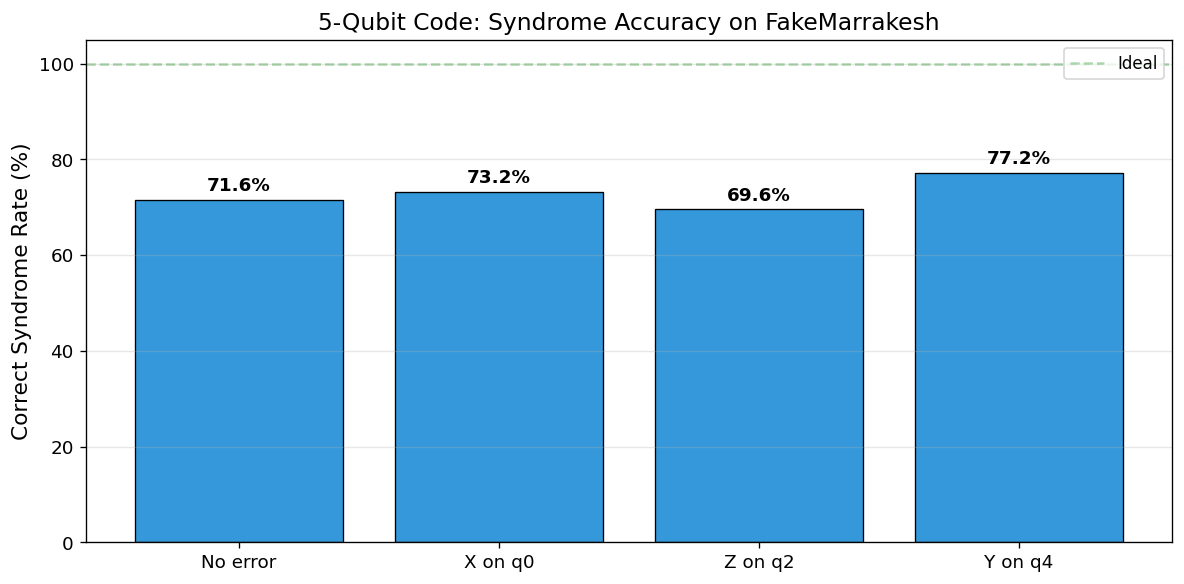

Note: The 5-qubit code uses 9 qubits (5 data + 4 ancilla) with
transpiled depth ~180. Lower syndrome accuracy vs the 3-qubit code
is expected due to deeper circuits accumulating more hardware noise.


In [70]:
test_cases_5q = {
    'No error':    None,
    'X on q0':     'IIIIX',
    'Z on q2':     'IIZII',
    'Y on q4':     'YIIII',
}

print("5-Qubit Code: Noisy Syndrome Extraction on FakeMarrakesh")
print("=" * 70)
print(f"Backend: {fake_backend.name}, Shots: {SHOTS}")
print()

results_5q_noisy = {}
for label, error_str in test_cases_5q.items():
    qc = build_syndrome_circuit(encode_5qubit, generators_5, 5, error_str)

    isa_qc = pm_fake.run(qc)
    job = sampler.run([isa_qc], shots=SHOTS)
    counts = job.result()[0].data.syndrome.get_counts()

    sorted_counts = sorted(counts.items(), key=lambda x: -x[1])
    top_syndrome = sorted_counts[0]

    ideal_syn_str = ideal_syndrome_str(error_str, generators_5)

    print(f"  {label:<12}")
    print(f"    Ideal syndrome:    {ideal_syn_str}")
    print(f"    Most common:       {top_syndrome[0]} ({top_syndrome[1]}/{SHOTS} = {top_syndrome[1]/SHOTS*100:.1f}%)")
    print(f"    Top 3 outcomes:    {sorted_counts[:3]}")

    results_5q_noisy[label] = {
        'counts': counts,
        'ideal': ideal_syn_str,
    }
    print()

fig, ax = plt.subplots(figsize=(10, 5))
labels_5 = list(results_5q_noisy.keys())
accuracies = []
for label in labels_5:
    r = results_5q_noisy[label]
    acc = r['counts'].get(r['ideal'], 0) / SHOTS * 100
    accuracies.append(acc)

colors = ['#3498db' if a > 50 else '#e74c3c' for a in accuracies]
bars = ax.bar(labels_5, accuracies, color=colors, edgecolor='black', linewidth=0.8)
ax.axhline(y=100, color='green', linestyle='--', alpha=0.3, label='Ideal')
ax.set_ylabel('Correct Syndrome Rate (%)', fontsize=13)
ax.set_title('5-Qubit Code: Syndrome Accuracy on FakeMarrakesh', fontsize=14)
ax.set_ylim(0, 105)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
            f'{acc:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print("Note: The 5-qubit code uses 9 qubits (5 data + 4 ancilla) with")
print("transpiled depth ~180. Lower syndrome accuracy vs the 3-qubit code")
print("is expected due to deeper circuits accumulating more hardware noise.")

---

## 5. The Steane Code [[7,1,3]]

### Theory

The **Steane code** is a [[7,1,3]] code that encodes 1 logical qubit into 7 physical qubits with distance 3. It belongs to the important family of **Calderbank-Shor-Steane (CSS) codes** — codes built from two classical linear codes, one for X-error correction and one for Z-error correction.

The Steane code is derived from the classical **[7,4,3] Hamming code**, the same code that corrects single bit-flip errors in classical computing. The parity check matrix of the Hamming code is:

$$H = \begin{pmatrix} 1 & 1 & 1 & 1 & 0 & 0 & 0 \\ 0 & 1 & 1 & 0 & 1 & 1 & 0 \\ 0 & 0 & 1 & 1 & 0 & 1 & 1 \end{pmatrix}$$

**CSS structure** (Qiskit convention: leftmost char = qubit 6, rightmost = qubit 0):

| Generator | Type | Pauli string | Qubits involved |
|-----------|------|-------------|-----------------|
| $g_1$ | X-type | `IIIXXXX` | 0, 1, 2, 3 |
| $g_2$ | X-type | `IXXIIXX` | 0, 1, 4, 5 |
| $g_3$ | X-type | `XIXIXIX` | 0, 2, 4, 6 |
| $g_4$ | Z-type | `IIIZZZZ` | 0, 1, 2, 3 |
| $g_5$ | Z-type | `IZZIIZZ` | 0, 1, 4, 5 |
| $g_6$ | Z-type | `ZIZIZIZ` | 0, 2, 4, 6 |

**CSS advantage:** X and Z errors can be corrected **independently**:
- **Z-type stabilizers** ($g_4, g_5, g_6$) detect **X errors** via CNOT(data, ancilla)
- **X-type stabilizers** ($g_1, g_2, g_3$) detect **Z errors** via H-CNOT(ancilla, data)-H

**Logical operators:**
$$X_L = XXXXXXX, \qquad Z_L = ZZZZZZZ$$

**Transversal Clifford gates:** The Steane code supports transversal $H$ (apply $H^{\otimes 7}$) and transversal $S$ (apply $S^{\otimes 7}$), making it attractive for fault-tolerant quantum computing.

### 5.1 Define Generators and Verify Commutativity

In [18]:
generators_steane_x = ['IIIXXXX', 'IXXIIXX', 'XIXIXIX']
generators_steane_z = ['IIIZZZZ', 'IZZIIZZ', 'ZIZIZIZ']
generators_steane = generators_steane_x + generators_steane_z

print("Steane Code: Generator Commutativity Check")
print("=" * 55)
all_commute = check_commutativity(generators_steane)
print(f"\nAll generators commute: {all_commute}")
print(f"Parameters: [[7, 1, 3]] -> k = 7 - 6 = {7 - len(generators_steane)} logical qubit")

syndrome_table_steane = build_syndrome_table(generators_steane, 7)
print(f"\nSyndrome table: {len(syndrome_table_steane)} entries")
print(f"  Expected: 22 (1 no-error + 21 single-qubit errors: 3 types x 7 qubits)")

Steane Code: Generator Commutativity Check
  [IIIXXXX] & [IXXIIXX]: commute = True
  [IIIXXXX] & [XIXIXIX]: commute = True
  [IIIXXXX] & [IIIZZZZ]: commute = True
  [IIIXXXX] & [IZZIIZZ]: commute = True
  [IIIXXXX] & [ZIZIZIZ]: commute = True
  [IXXIIXX] & [XIXIXIX]: commute = True
  [IXXIIXX] & [IIIZZZZ]: commute = True
  [IXXIIXX] & [IZZIIZZ]: commute = True
  [IXXIIXX] & [ZIZIZIZ]: commute = True
  [XIXIXIX] & [IIIZZZZ]: commute = True
  [XIXIXIX] & [IZZIIZZ]: commute = True
  [XIXIXIX] & [ZIZIZIZ]: commute = True
  [IIIZZZZ] & [IZZIIZZ]: commute = True
  [IIIZZZZ] & [ZIZIZIZ]: commute = True
  [IZZIIZZ] & [ZIZIZIZ]: commute = True

All generators commute: True
Parameters: [[7, 1, 3]] -> k = 7 - 6 = 1 logical qubit

Syndrome table: 22 entries
  Expected: 22 (1 no-error + 21 single-qubit errors: 3 types x 7 qubits)


### 5.2 Build the Steane Encoding Circuit

The encoding uses the structure from the Hamming code parity check matrix. Qubit 0 is the logical input; qubits 1-6 are ancillae initialized to $|0\rangle$.

Steane Encoding Circuit:
  Qubits: 7
  Depth:  13
  Gates:  {'cx': 13, 'h': 3, 'swap': 1}


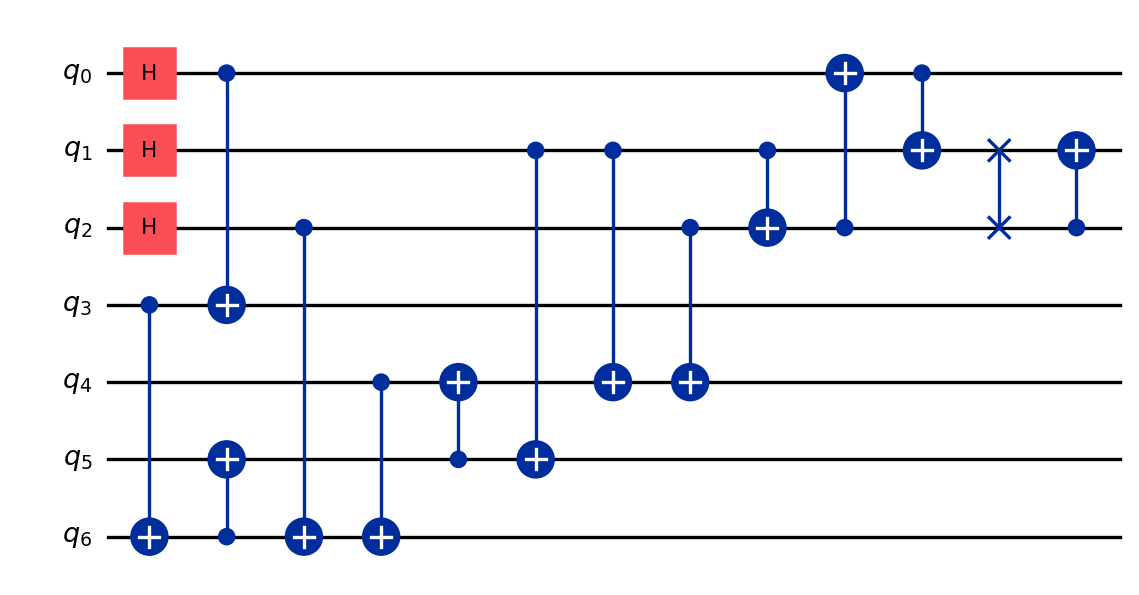

In [19]:
def encode_steane():
    """Encoding circuit for [[7,1,3]] Steane code derived from StabilizerState."""
    stab = StabilizerState.from_stabilizer_list(generators_steane + ['ZZZZZZZ'])
    return stab.clifford.to_circuit()


enc_steane = encode_steane()
print(f"Steane Encoding Circuit:")
print(f"  Qubits: {enc_steane.num_qubits}")
print(f"  Depth:  {enc_steane.depth()}")
print(f"  Gates:  {dict(enc_steane.count_ops())}")
enc_steane.draw('mpl', style='iqp')

### 5.3 Verify the Steane Encoding

We verify the encoding by checking all 6 stabilizer generators and logical operators. We also inspect the $|0_L\rangle$ codeword — it should be an equal superposition of 8 computational basis states (since the Hamming code has $2^k = 2^4 = 16$ codewords, and the Steane code uses half of them for $|0_L\rangle$).

In [20]:
print("Steane Code: Encoding Verification")
print("=" * 60)

# Encode |0> -> |0_L>
qc_0L_s = QuantumCircuit(7)
qc_0L_s.compose(encode_steane(), inplace=True)

# |1_L> = X_L |0_L>, where X_L = XXXXXXX
qc_1L_s = QuantumCircuit(7)
qc_1L_s.compose(encode_steane(), inplace=True)
for i in range(7):
    qc_1L_s.x(i)

for label, qc in [('|0_L>', qc_0L_s), ('|1_L>', qc_1L_s)]:
    result = verify_stabilizers(qc, generators_steane)
    all_pass = all(abs(v - 1.0) < 1e-10 for v in result.values())
    print(f"\n  {label}  [{'PASS' if all_pass else 'FAIL'}]")
    for g, val in result.items():
        g_type = "X-type" if g in generators_steane_x else "Z-type"
        status = "ok" if abs(val - 1.0) < 1e-10 else "FAIL"
        print(f"    <{g}> ({g_type}) = {val:+.6f}  [{status}]")

print("\nLogical Operator Expectations:")
print("-" * 45)
sv_0L_s = Statevector.from_instruction(qc_0L_s)
sv_1L_s = Statevector.from_instruction(qc_1L_s)

zl_0 = np.real(sv_0L_s.expectation_value(Pauli('ZZZZZZZ')))
zl_1 = np.real(sv_1L_s.expectation_value(Pauli('ZZZZZZZ')))
print(f"  <0_L|Z_L|0_L> = {zl_0:+.4f}  (expect +1)")
print(f"  <1_L|Z_L|1_L> = {zl_1:+.4f}  (expect -1)")

print("\n|0_L> Codeword Structure:")
print("-" * 45)
probs = sv_0L_s.probabilities_dict()
nonzero = {k: v for k, v in sorted(probs.items()) if v > 1e-10}
print(f"  {len(nonzero)} basis states with equal amplitude 1/sqrt({len(nonzero)}):")
for bitstring, prob in nonzero.items():
    print(f"    |{bitstring}> : probability = {prob:.4f}")

Steane Code: Encoding Verification

  |0_L>  [PASS]
    <IIIXXXX> (X-type) = +1.000000  [ok]
    <IXXIIXX> (X-type) = +1.000000  [ok]
    <XIXIXIX> (X-type) = +1.000000  [ok]
    <IIIZZZZ> (Z-type) = +1.000000  [ok]
    <IZZIIZZ> (Z-type) = +1.000000  [ok]
    <ZIZIZIZ> (Z-type) = +1.000000  [ok]

  |1_L>  [PASS]
    <IIIXXXX> (X-type) = +1.000000  [ok]
    <IXXIIXX> (X-type) = +1.000000  [ok]
    <XIXIXIX> (X-type) = +1.000000  [ok]
    <IIIZZZZ> (Z-type) = +1.000000  [ok]
    <IZZIIZZ> (Z-type) = +1.000000  [ok]
    <ZIZIZIZ> (Z-type) = +1.000000  [ok]

Logical Operator Expectations:
---------------------------------------------
  <0_L|Z_L|0_L> = +1.0000  (expect +1)
  <1_L|Z_L|1_L> = -1.0000  (expect -1)

|0_L> Codeword Structure:
---------------------------------------------
  8 basis states with equal amplitude 1/sqrt(8):
    |0000000> : probability = 0.1250
    |0001111> : probability = 0.1250
    |0110011> : probability = 0.1250
    |0111100> : probability = 0.1250
    |1010101>

### 5.4 CSS Syndrome Extraction: Independent X and Z Error Detection

The defining feature of CSS codes is that **X errors and Z errors are detected by separate sets of stabilizers**:
- **Z-type stabilizers** ($g_4, g_5, g_6$) detect X errors using CNOT(data → ancilla)
- **X-type stabilizers** ($g_1, g_2, g_3$) detect Z errors using H-CNOT(ancilla → data)-H

This means we can build simpler, separate syndrome circuits for each error type.

Steane CSS Syndrome Extraction Circuit:
  Data qubits: 7, Ancilla qubits: 6 (3 Z-type + 3 X-type)
  Total qubits:   13
  Circuit depth:  28


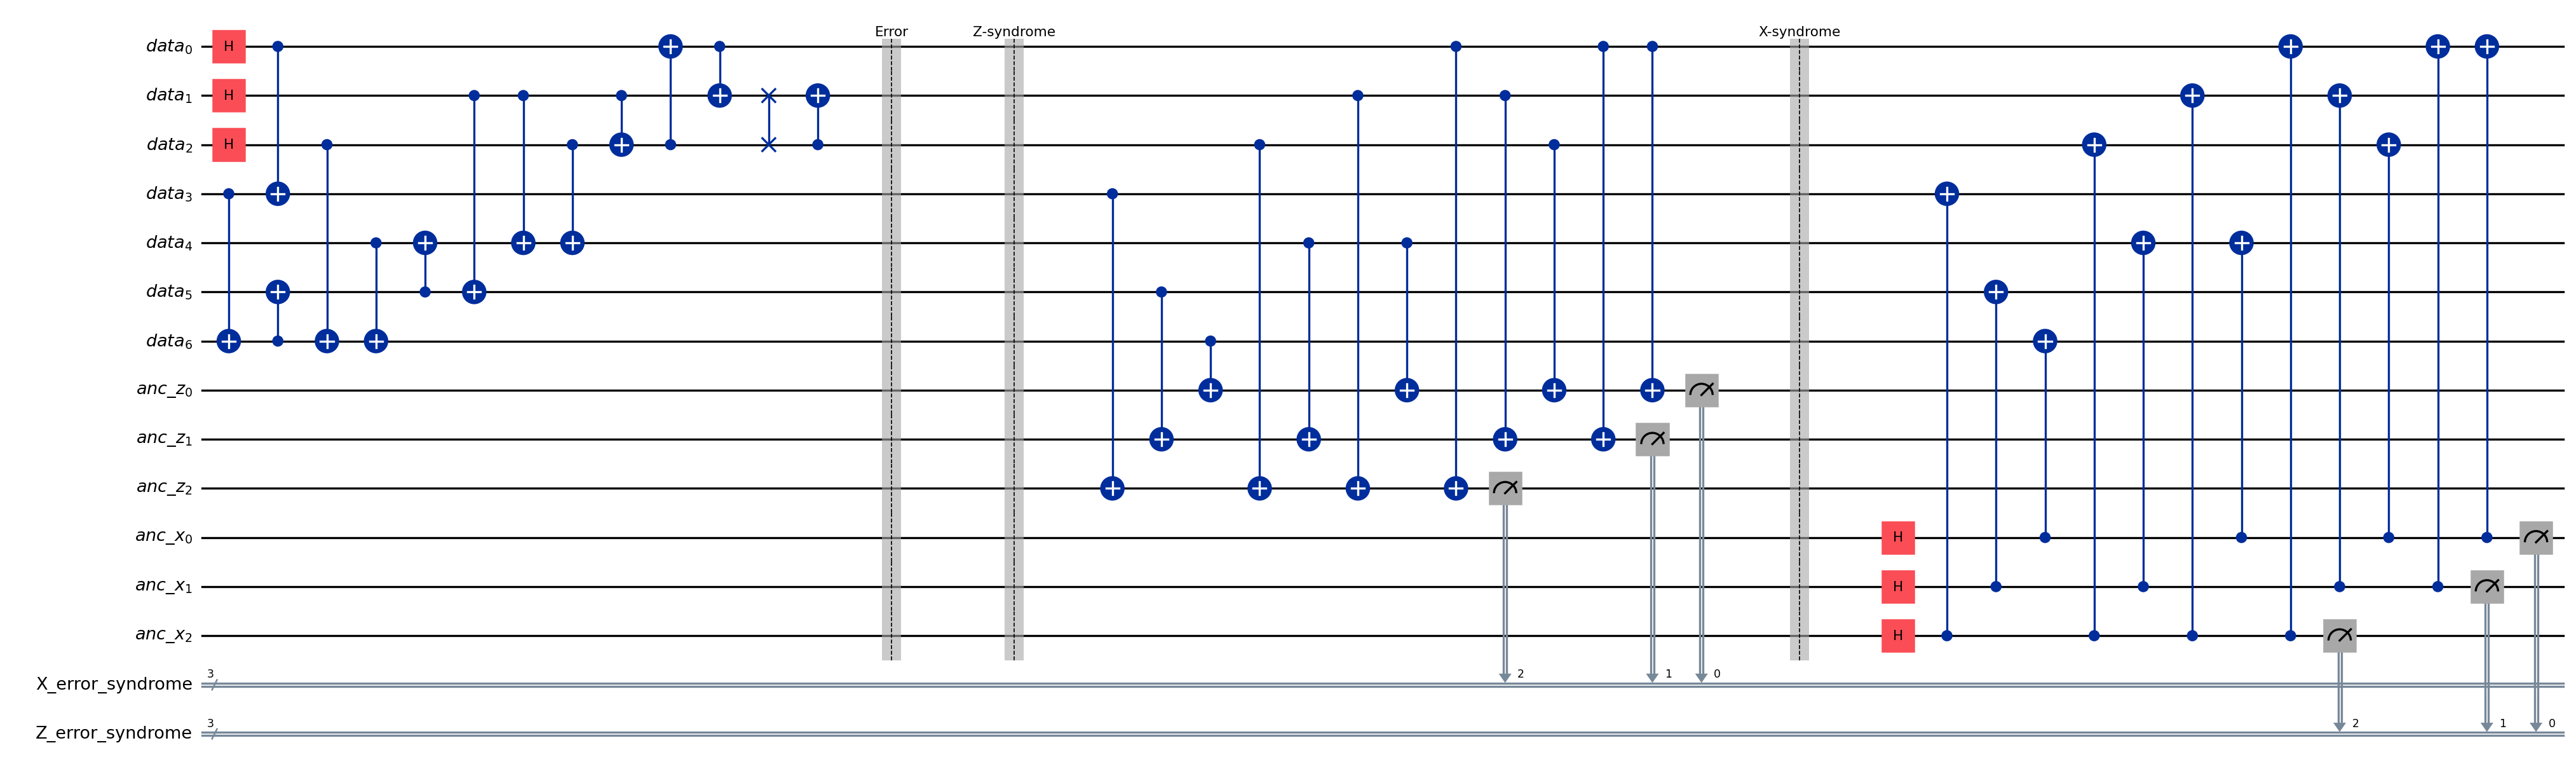

In [76]:
def steane_css_syndrome_circuit(error_str=None):
    """
    Build the CSS syndrome extraction circuit for the Steane code.

    Z-type syndrome (detects X errors):
      For each Z-type generator, CNOT from each data qubit in the
      generator's support to the ancilla.

    X-type syndrome (detects Z errors):
      For each X-type generator, prepare ancilla in |+>,
      CNOT from ancilla to each data qubit in support, then H and measure.

    Args:
        error_str: Pauli error string (Qiskit convention), or None
    """
    n = 7
    data = QuantumRegister(n, 'data')
    anc_z = QuantumRegister(3, 'anc_z')
    anc_x = QuantumRegister(3, 'anc_x')
    syn_x_err = ClassicalRegister(3, 'X_error_syndrome')
    syn_z_err = ClassicalRegister(3, 'Z_error_syndrome')
    qc = QuantumCircuit(data, anc_z, anc_x, syn_x_err, syn_z_err)

    qc.compose(encode_steane(), qubits=data, inplace=True)
    qc.barrier(label='Error')

    if error_str:
        apply_pauli_string(qc, error_str, qubits=data)
    qc.barrier(label='Z-syndrome')

    for k, gen in enumerate(generators_steane_z):
        a = 2 - k
        support = [n - 1 - j for j, p in enumerate(gen) if p == "Z"]
        for q in support:
            qc.cx(data[q], anc_z[a])
    qc.measure(anc_z, syn_x_err)

    qc.barrier(label='X-syndrome')

    for k, gen in enumerate(generators_steane_x):
        a = 2 - k
        support = [n - 1 - j for j, p in enumerate(gen) if p == "X"]
        qc.h(anc_x[a])
        for q in support:
            qc.cx(anc_x[a], data[q])
    qc.measure(anc_x, syn_z_err)

    return qc


demo_css = steane_css_syndrome_circuit()
print(f"Steane CSS Syndrome Extraction Circuit:")
print(f"  Data qubits: 7, Ancilla qubits: 6 (3 Z-type + 3 X-type)")
print(f"  Total qubits:   {demo_css.num_qubits}")
print(f"  Circuit depth:  {demo_css.depth()}")
demo_css.draw('mpl', style='iqp', fold=-1, idle_wires=False)

### 5.5 Demonstrate Independent X/Z Error Detection

The hallmark of CSS codes: an X error triggers **only** the Z-type syndrome, a Z error triggers **only** the X-type syndrome, and a Y error ($=iXZ$) triggers **both**.

In [77]:
print("Steane Code: Independent X/Z Error Detection (CSS Property)")
print("=" * 75)
print(f"{'Error':<14} {'Z-syn (detects X)':<20} {'X-syn (detects Z)':<20} {'Type'}")
print("-" * 75)

for qubit in range(7):
    for pauli in ['X', 'Z', 'Y']:
        error_label = make_error_string(qubit, pauli, 7)

        qc = QuantumCircuit(7)
        qc.compose(encode_steane(), inplace=True)
        if pauli == 'X': qc.x(qubit)
        elif pauli == 'Y': qc.y(qubit)
        elif pauli == 'Z': qc.z(qubit)

        z_syndrome = get_syndrome(qc, generators_steane_z)
        x_syndrome = get_syndrome(qc, generators_steane_x)

        z_str = format_syndrome(z_syndrome)
        x_str = format_syndrome(x_syndrome)

        z_fires = any(s == -1 for s in z_syndrome)
        x_fires = any(s == -1 for s in x_syndrome)

        if z_fires and not x_fires:
            err_type = "X-error only"
        elif x_fires and not z_fires:
            err_type = "Z-error only"
        elif z_fires and x_fires:
            err_type = "Both (Y=iXZ)"
        else:
            err_type = "Undetected"

        print(f"  {error_label:<14} ({z_str}){'':>11} ({x_str}){'':>11} {err_type}")

    if qubit < 6:
        print()

print("\nCSS property confirmed: X and Z errors are detected independently!")

Steane Code: Independent X/Z Error Detection (CSS Property)
Error          Z-syn (detects X)    X-syn (detects Z)    Type
---------------------------------------------------------------------------
  IIIIIIX        (---)            (+++)            X-error only
  IIIIIIZ        (+++)            (---)            Z-error only
  IIIIIIY        (---)            (---)            Both (Y=iXZ)

  IIIIIXI        (--+)            (+++)            X-error only
  IIIIIZI        (+++)            (--+)            Z-error only
  IIIIIYI        (--+)            (--+)            Both (Y=iXZ)

  IIIIXII        (-+-)            (+++)            X-error only
  IIIIZII        (+++)            (-+-)            Z-error only
  IIIIYII        (-+-)            (-+-)            Both (Y=iXZ)

  IIIXIII        (-++)            (+++)            X-error only
  IIIZIII        (+++)            (-++)            Z-error only
  IIIYIII        (-++)            (-++)            Both (Y=iXZ)

  IIXIIII        (+--)        

### 5.6 Full Error Correction Verification

Verify that the Steane code can correct all 21 single-qubit errors (X, Y, Z on each of 7 qubits).

In [78]:
qc_ref_s = QuantumCircuit(7)
qc_ref_s.compose(encode_steane(), inplace=True)
sv_ref_s = Statevector.from_instruction(qc_ref_s)

print("Steane Code: Error Correction Fidelity Verification")
print("=" * 65)
print(f"{'Error':<14} {'Full Syndrome':<18} {'Correction':<14} {'Fidelity':<10} {'Status'}")
print("-" * 65)

all_pass_steane = True
for qubit in range(7):
    for pauli in ['X', 'Y', 'Z']:
        error_label = make_error_string(qubit, pauli, 7)

        qc = QuantumCircuit(7)
        qc.compose(encode_steane(), inplace=True)
        apply_pauli_string(qc, error_label)

        syndrome = get_syndrome(qc, generators_steane)
        correction = syndrome_table_steane.get(tuple(syndrome), None)

        if correction:
            apply_pauli_string(qc, correction)

        sv_corrected = Statevector.from_instruction(qc)
        fid = state_fidelity(sv_corrected, sv_ref_s)

        status = "PASS" if abs(fid - 1.0) < 1e-10 else "FAIL"
        if status == "FAIL":
            all_pass_steane = False

        syn_str = format_syndrome(syndrome)
        print(f"  {error_label:<14} ({syn_str})    {correction:<14} {fid:.6f}   {status}")

print(f"\n{'All 21 errors corrected!' if all_pass_steane else 'Some corrections FAILED.'}")
print("The Steane [[7,1,3]] code corrects any single-qubit error.")

Steane Code: Error Correction Fidelity Verification
Error          Full Syndrome      Correction     Fidelity   Status
-----------------------------------------------------------------
  IIIIIIX        (+++---)    IIIIIIX        1.000000   PASS
  IIIIIIY        (------)    IIIIIIY        1.000000   PASS
  IIIIIIZ        (---+++)    IIIIIIZ        1.000000   PASS
  IIIIIXI        (+++--+)    IIIIIXI        1.000000   PASS
  IIIIIYI        (--+--+)    IIIIIYI        1.000000   PASS
  IIIIIZI        (--++++)    IIIIIZI        1.000000   PASS
  IIIIXII        (+++-+-)    IIIIXII        1.000000   PASS
  IIIIYII        (-+--+-)    IIIIYII        1.000000   PASS
  IIIIZII        (-+-+++)    IIIIZII        1.000000   PASS
  IIIXIII        (+++-++)    IIIXIII        1.000000   PASS
  IIIYIII        (-++-++)    IIIYIII        1.000000   PASS
  IIIZIII        (-+++++)    IIIZIII        1.000000   PASS
  IIXIIII        (++++--)    IIXIIII        1.000000   PASS
  IIYIIII        (+--+--)    IIYIII

### 5.7 Noisy Simulation on FakeMarrakesh

Let's run the Steane code's syndrome extraction circuit on the noisy FakeMarrakesh simulator. We use the general `build_syndrome_circuit` function and analyze how noise affects syndrome measurement accuracy.

Steane Code: Noisy Syndrome Extraction on FakeMarrakesh
Backend: fake_marrakesh, Shots: 4096

  No error    
    Ideal syndrome:    000000
    Most common:       000000 (2405/4096 = 58.7%)
    Top 3 outcomes:    [('000000', 2405), ('000001', 206), ('000010', 140)]

  X on q3     
    Ideal syndrome:    000100
    Most common:       000100 (2726/4096 = 66.6%)
    Top 3 outcomes:    [('000100', 2726), ('000000', 149), ('000101', 113)]

  Z on q5     
    Ideal syndrome:    010000
    Most common:       010000 (2470/4096 = 60.3%)
    Top 3 outcomes:    [('010000', 2470), ('010001', 158), ('010100', 136)]

  Y on q0     
    Ideal syndrome:    111111
    Most common:       111111 (2333/4096 = 57.0%)
    Top 3 outcomes:    [('111111', 2333), ('111110', 236), ('110111', 169)]



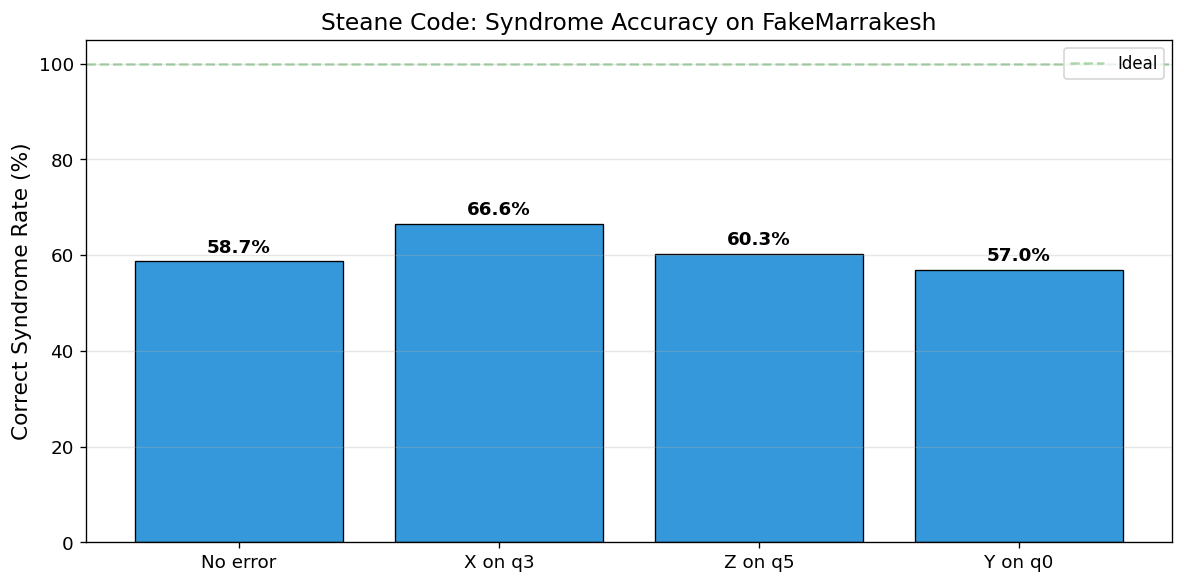

Note: The Steane code uses 13 qubits (7 data + 6 ancilla) with
transpiled depth ~230. Syndrome accuracy of 60-70% is expected at
this circuit depth on current noisy hardware.


In [79]:
test_cases_steane = {
    'No error':    None,
    'X on q3':     'IIIXIII',
    'Z on q5':     'IZIIIII',
    'Y on q0':     'IIIIIIY',
}

print("Steane Code: Noisy Syndrome Extraction on FakeMarrakesh")
print("=" * 70)
print(f"Backend: {fake_backend.name}, Shots: {SHOTS}")
print()

results_steane_noisy = {}
for label, error_str in test_cases_steane.items():
    qc = build_syndrome_circuit(encode_steane, generators_steane, 7, error_str)

    isa_qc = pm_fake.run(qc)
    job = sampler.run([isa_qc], shots=SHOTS)
    counts = job.result()[0].data.syndrome.get_counts()

    sorted_counts = sorted(counts.items(), key=lambda x: -x[1])
    top_syndrome = sorted_counts[0]

    ideal_syn = ideal_syndrome_str(error_str, generators_steane)

    print(f"  {label:<12}")
    print(f"    Ideal syndrome:    {ideal_syn}")
    print(f"    Most common:       {top_syndrome[0]} ({top_syndrome[1]}/{SHOTS} = {top_syndrome[1]/SHOTS*100:.1f}%)")
    print(f"    Top 3 outcomes:    {sorted_counts[:3]}")

    results_steane_noisy[label] = {
        'counts': counts,
        'ideal': ideal_syn,
    }
    print()

fig, ax = plt.subplots(figsize=(10, 5))
labels_s = list(results_steane_noisy.keys())
accuracies = []
for label in labels_s:
    r = results_steane_noisy[label]
    acc = r['counts'].get(r['ideal'], 0) / SHOTS * 100
    accuracies.append(acc)

colors = ['#3498db' if a > 50 else '#e74c3c' for a in accuracies]
bars = ax.bar(labels_s, accuracies, color=colors, edgecolor='black', linewidth=0.8)
ax.axhline(y=100, color='green', linestyle='--', alpha=0.3, label='Ideal')
ax.set_ylabel('Correct Syndrome Rate (%)', fontsize=13)
ax.set_title('Steane Code: Syndrome Accuracy on FakeMarrakesh', fontsize=14)
ax.set_ylim(0, 105)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
            f'{acc:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print("Note: The Steane code uses 13 qubits (7 data + 6 ancilla) with")
print("transpiled depth ~230. Syndrome accuracy of 60-70% is expected at")
print("this circuit depth on current noisy hardware.")

---

## 6. Comparison of All Three Codes

### Summary Table

| Property | [[3,1,1]] Repetition | [[5,1,3]] Perfect | [[7,1,3]] Steane |
|----------|---------------------|-------------------|------------------|
| **Physical qubits** ($n$) | 3 | 5 | 7 |
| **Logical qubits** ($k$) | 1 | 1 | 1 |
| **Distance** ($d$) | 3 (X only) | 3 | 3 |
| **Generators** ($r$) | 2 | 4 | 6 |
| **Correctable errors** | 1 bit-flip | 1 arbitrary | 1 arbitrary |
| **Error types corrected** | X only | X, Y, Z | X, Y, Z |
| **Code type** | Repetition | General stabilizer | CSS |
| **Syndrome qubits** | 2 | 4 | 6 |
| **Unique syndromes** | 4 | 16 | 22 (but with redundancy) |
| **Transversal H** | No | No | Yes ($H^{\otimes 7}$) |
| **Transversal S** | No | No | Yes ($S^{\otimes 7}$) |
| **Transversal CNOT** | Yes | No | Yes |
| **Independent X/Z correction** | N/A | No | Yes (CSS) |

### Why Noisy Syndrome Accuracy Varies

The 3-qubit code achieves ~95% correction success on FakeMarrakesh, while the 5-qubit and Steane codes show 60-70% syndrome accuracy. This is **expected** and reflects a fundamental tradeoff:

| Factor | [[3,1,1]] | [[5,1,3]] | [[7,1,3]] |
|--------|-----------|-----------|-----------|
| Total qubits | 5 | 9 | 13 |
| Transpiled depth | ~11 | ~180 | ~230 |
| Syndrome bits | 2 | 4 | 6 |

More qubits and deeper circuits accumulate more hardware noise per syndrome extraction round. In practice, real QEC systems overcome this by using **repeated syndrome rounds** with a **decoder algorithm** (e.g., minimum-weight perfect matching) that identifies the most likely error pattern from noisy syndrome histories.

### 6.1 Circuit Depth Comparison

How do the encoding and syndrome circuits compare in terms of transpiled depth?

Circuit Depth Comparison (Encoding + Syndrome Extraction)
Code            Raw Depth    Transpiled Depth   Total Qubits   CX Count
-----------------------------------------------------------------
  3-qubit [[3,1,1]] 5            11                 5              0
  5-qubit [[5,1,3]] 28           163                9              0
  7-qubit [[7,1,3]] 25           186                13             0


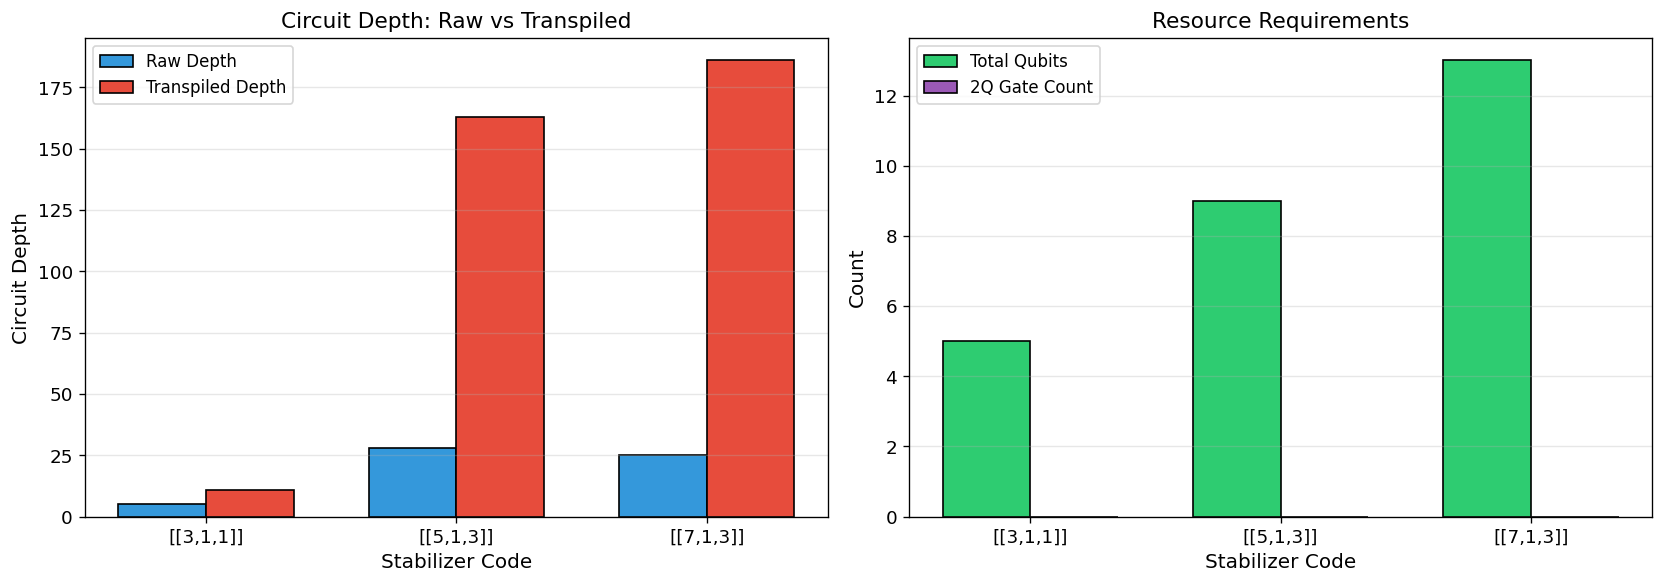


Key insight: More powerful codes require more qubits and deeper circuits,
increasing the impact of hardware noise. This is the fundamental tradeoff
in quantum error correction.


In [25]:
# ---- Compare circuit depths across all three codes ----
# Build syndrome circuits for each code (no error)
syn_3q = syndrome_extraction_3qubit()
syn_5q = build_syndrome_circuit(encode_5qubit, generators_5, 5)
syn_7q = build_syndrome_circuit(encode_steane, generators_steane, 7)

circuits = {
    '3-qubit\n[[3,1,1]]': syn_3q,
    '5-qubit\n[[5,1,3]]': syn_5q,
    '7-qubit\n[[7,1,3]]': syn_7q,
}

print("Circuit Depth Comparison (Encoding + Syndrome Extraction)")
print("=" * 65)
print(f"{'Code':<15} {'Raw Depth':<12} {'Transpiled Depth':<18} {'Total Qubits':<14} {'CX Count'}")
print("-" * 65)

raw_depths = []
transpiled_depths = []
total_qubits = []
cx_counts = []

for label, qc in circuits.items():
    raw_d = qc.depth()
    isa_qc = pm_fake.run(qc)
    trans_d = isa_qc.depth()
    n_qubits = qc.num_qubits
    # Count CX (or ECR) gates in transpiled circuit
    ops = dict(isa_qc.count_ops())
    cx_count = ops.get('cx', 0) + ops.get('ecr', 0)
    
    raw_depths.append(raw_d)
    transpiled_depths.append(trans_d)
    total_qubits.append(n_qubits)
    cx_counts.append(cx_count)
    
    print(f"  {label.replace(chr(10), ' '):<15} {raw_d:<12} {trans_d:<18} {n_qubits:<14} {cx_count}")

# ---- Side-by-side bar chart ----
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

code_labels = ['[[3,1,1]]', '[[5,1,3]]', '[[7,1,3]]']
x = np.arange(len(code_labels))
width = 0.35

# Left: Depth comparison
bars1 = ax1.bar(x - width/2, raw_depths, width, label='Raw Depth', color='#3498db', edgecolor='black')
bars2 = ax1.bar(x + width/2, transpiled_depths, width, label='Transpiled Depth', color='#e74c3c', edgecolor='black')
ax1.set_xlabel('Stabilizer Code', fontsize=12)
ax1.set_ylabel('Circuit Depth', fontsize=12)
ax1.set_title('Circuit Depth: Raw vs Transpiled', fontsize=13)
ax1.set_xticks(x)
ax1.set_xticklabels(code_labels)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3, axis='y')

# Right: Resource comparison
bars3 = ax2.bar(x - width/2, total_qubits, width, label='Total Qubits', color='#2ecc71', edgecolor='black')
bars4 = ax2.bar(x + width/2, cx_counts, width, label='2Q Gate Count', color='#9b59b6', edgecolor='black')
ax2.set_xlabel('Stabilizer Code', fontsize=12)
ax2.set_ylabel('Count', fontsize=12)
ax2.set_title('Resource Requirements', fontsize=13)
ax2.set_xticks(x)
ax2.set_xticklabels(code_labels)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\nKey insight: More powerful codes require more qubits and deeper circuits,")
print("increasing the impact of hardware noise. This is the fundamental tradeoff")
print("in quantum error correction.")

---

## 7. Key Takeaways

1. **The stabilizer formalism provides a unified framework** for defining, analyzing, and implementing quantum error-correcting codes. All codes share the same pattern: define generators → derive syndromes → build lookup tables → apply corrections.

2. **Progressive complexity, progressive capability:**
   - The **[[3,1,1]] repetition code** protects only against bit-flips (X errors) — a single error type
   - The **[[5,1,3]] perfect code** is the smallest code correcting any single-qubit error (X, Y, or Z) — it saturates the quantum Hamming bound
   - The **[[7,1,3]] Steane code** adds the CSS structure, enabling independent X/Z correction and transversal Clifford gates

3. **CSS codes offer practical advantages** for fault-tolerant quantum computing:
   - Simpler syndrome extraction circuits (separate X and Z measurements)
   - Transversal logical Clifford gates ($H$, $S$, CNOT) — critical for fault tolerance
   - Natural connection to classical coding theory (Hamming codes)

4. **The fundamental tradeoff:** More powerful codes need more qubits and deeper circuits, making them more susceptible to hardware noise. Quantum error correction only helps when the physical error rate is below the code's **threshold** — the point where encoding actually improves logical fidelity.

5. **Connection to fault tolerance:** The Steane code's transversal Clifford gates, combined with **magic state injection** (covered in the `magic_states.ipynb` notebook), provide a path to **universal fault-tolerant quantum computation**. This is the foundation of the leading approach to scalable quantum computing.

---

## References

- [IBM Quantum Learning: Stabilizer Codes](https://quantum.cloud.ibm.com/learning/en/courses/foundations-of-quantum-error-correction/stabilizer-formalism/stabilizer-codes) — Primary reference for this notebook
- [Qiskit Documentation: StabilizerState](https://docs.quantum.ibm.com/api/qiskit/qiskit.quantum_info.StabilizerState) — Qiskit API reference

In [26]:
import qiskit
import qiskit_ibm_runtime

print("Environment:")
print(f"  Qiskit SDK:     {qiskit.__version__}")
print(f"  Qiskit Runtime: {qiskit_ibm_runtime.__version__}")

Environment:
  Qiskit SDK:     2.3.0
  Qiskit Runtime: 0.41.1
